In [1]:
#tiling orb
%pip install -U npc_lims

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
import datetime
import zoneinfo
import re
import npc_sessions
import npc_lims
from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import data_utils, spike_utils



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\vayle.lafehr\AppData\Local\anaconda3\envs\dr_analysis\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## ORBm data

In [2]:
muscimol_data_orbm = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['823577_2026-03-09', '823577_2026-03-10', '823577_2026-03-16', '823577_2026-03-17','832032_2026-03-09','832032_2026-03-10','832032_2026-03-02', '832032_2026-03-03','824636_2026-01-21','807743_2025-11-03','807743_2025-11-04', '807743_2025-11-10', '807743_2025-11-11','813582_2025-12-08','813582_2025-12-09','813582_2025-12-15','813582_2025-12-16', '824636_2026-01-12', '824636_2026-01-13', '824636_2026-01-20']
control = ['823577_2026-03-09','823577_2026-03-16','832032_2026-03-09','832032_2026-03-02','807743_2025-11-03', '807743_2025-11-10', '813582_2025-12-08', '813582_2025-12-15', '824636_2026-01-12', '824636_2026-01-21']
perturbation = ['823577_2026-03-10','823577_2026-03-17','832032_2026-03-10','832032_2026-03-03','807743_2025-11-04', '807743_2025-11-11', '813582_2025-12-09', '813582_2025-12-16', '824636_2026-01-13', '824636_2026-01-20']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_orbm.append(result)

# print(muscimol_data)
muscimol_df_orbm = pd.DataFrame(muscimol_data_orbm)
print(muscimol_df_orbm)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                    session_id  control  perturbation  \
0   DynamicRoutingSession('823577_2026-03-09')     True         False   
1   DynamicRoutingSession('823577_2026-03-10')    False          True   
2   DynamicRoutingSession('823577_2026-03-16')     True         False   
3   DynamicRoutingSession('823577_2026-03-17')    False          True   
4   DynamicRoutingSession('832032_2026-03-09')     True         False   
5   DynamicRoutingSession('832032_2026-03-10')    False          True   
6   DynamicRoutingSession('832032_2026-03-02')     True         False   
7   DynamicRoutingSession('832032_2026-03-03')    False          True   
8   DynamicRoutingSession('824636_2026-01-21')     True         False   
9   DynamicRoutingSession('807743_2025-11-03')     True         False   
10  DynamicRoutingSession('807743_2025-11-04')    False          True   
11  DynamicRoutingSession('807743_2025-11-10')     True         False   
12  DynamicRoutingSession('807743_2025-11-11')    F

In [ ]:
[0.92957746 0.58571429 1.         0.97333333 0.97183099 0.95945946]

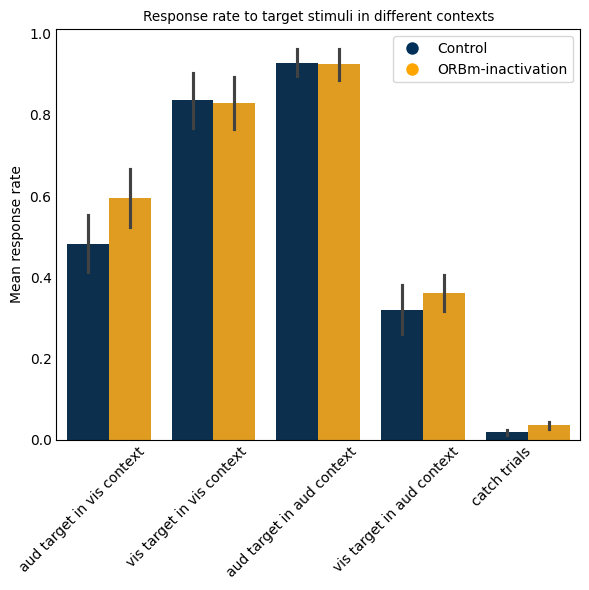

In [11]:
muscimol_df_orbm['session_id'] = muscimol_df_orbm['session_id'].astype(str)

avg_orbm = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['visual_target_in_visual_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_orbm[muscimol_df_orbm['control']]['catch_trials'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_orbm_df = pd.DataFrame(avg_orbm)

avg_orbm_melted = avg_orbm_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_orbm_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORBm-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



       Condition                   Category  Mean Value
0        Control  aud target in vis context    0.421053
0        Control  aud target in vis context    0.262295
0        Control  aud target in vis context    0.250000
0        Control  aud target in vis context    0.237288
0        Control  aud target in vis context    0.785714
..           ...                        ...         ...
9   Perturbation               catch trials    0.058824
9   Perturbation               catch trials    0.020833
9   Perturbation               catch trials    0.035714
9   Perturbation               catch trials    0.065217
9   Perturbation               catch trials    0.000000

[70 rows x 3 columns]


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_29584\3770279435.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x='Category', y='Mean Value', hue='Condition',


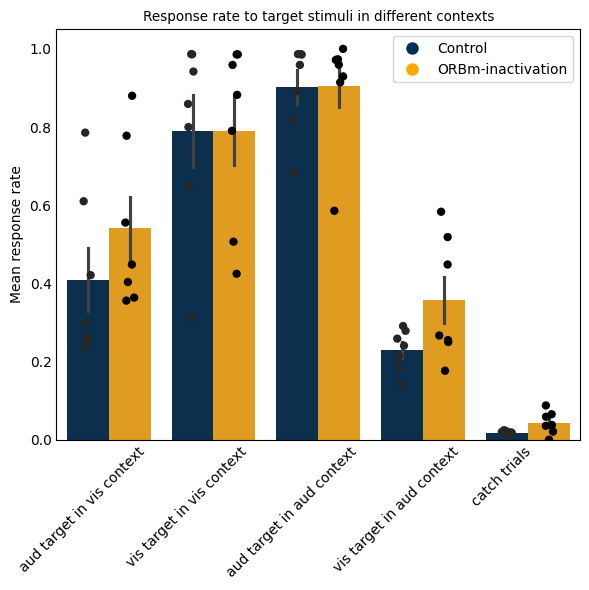

In [10]:
import seaborn as sns

# Create a DataFrame from the dictionary
avg_orbm = pd.DataFrame(avg_orbm)
avg_orbm
avg_orbm_melt = avg_orbm.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_orbm_melt.explode('Mean Value'), palette=['#003057', '#FFA500'])

# Add individual data points on top of bars
import pandas as pd
exploded_data = avg_orbm_melt.explode('Mean Value')
exploded_data['Mean Value'] = pd.to_numeric(exploded_data['Mean Value'])

print(exploded_data)

sns.stripplot(x='Category', y='Mean Value', hue='Condition', 
              data=exploded_data, dodge=True, 
              color='black', alpha=1, size=6, ax=ax, legend=False)

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks]
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)

plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORBm-inactivation']
plt.legend(handles, labels, loc='upper right')

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()

In [11]:
import re

def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

In [12]:
unique_groups = muscimol_df_orbm['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}


KeyError: 'color_group'

In [13]:
import seaborn as sns
import pandas as pd
import re
from datetime import datetime

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Add mouse ID to muscimol_df_orbm
muscimol_df_orbm['mouse_id'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)

# Create color map for mouse IDs
unique_mice = muscimol_df_orbm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Create a DataFrame with behavioral data and mouse IDs together
control_data = muscimol_df_orbm[muscimol_df_orbm['control']]
perturb_data = muscimol_df_orbm[muscimol_df_orbm['perturbation']]

avg_orbm_with_mice = {
    'Condition': ['Control', 'Perturbation'],
    'aud target in vis context':[
        control_data['auditory_target_in_visual_context'].values,
        perturb_data['auditory_target_in_visual_context'].values
    ],
    'vis target in vis context':[
        control_data['visual_target_in_visual_context'].values,
        perturb_data['visual_target_in_visual_context'].values
    ],
    'aud target in aud context':[
        control_data['auditory_target_in_auditory_context'].values,
        perturb_data['auditory_target_in_auditory_context'].values
    ],
    'vis target in aud context':[
        control_data['visual_target_in_auditory_context'].values,
        perturb_data['visual_target_in_auditory_context'].values
    ],
    'catch trials' :[
        control_data['catch_trials'].values,
        perturb_data['catch_trials'].values
    ],
    'mouse_id': [
        control_data['mouse_id'].values,
        perturb_data['mouse_id'].values
    ]
}

# Create dataframe and melt
avg_orbm_df = pd.DataFrame(avg_orbm_with_mice)
avg_orbm_melt = avg_orbm_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Explode all data at once
exploded_data = avg_orbm_melt.explode('Mean Value').reset_index(drop=True)

# Separate mouse_id and behavioral data
mouse_ids = exploded_data[exploded_data['Category'] == 'mouse_id']['Mean Value'].values
exploded_data = exploded_data[exploded_data['Category'] != 'mouse_id'].reset_index(drop=True)

# Convert to numeric and add mouse IDs (repeat mouse IDs for each category)
exploded_data['Mean Value'] = pd.to_numeric(exploded_data['Mean Value'])
n_categories = len(exploded_data['Category'].unique())
# exploded_data['mouse_id'] = np.repeat(mouse_ids, n_categories // len(mouse_ids))

# Map colors
exploded_data['color'] = exploded_data['mouse_id'].map(mouse_color_map)

# Plotting
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=exploded_data, palette=['#003057', '#FFA500'])

# Add individual data points colored by mouse ID
for idx, row in exploded_data.iterrows():
    category_pos = list(exploded_data['Category'].unique()).index(row['Category'])
    condition_offset = -0.2 if row['Condition'] == 'Control' else 0.2
    x_pos = category_pos + condition_offset
    ax.scatter(x_pos, row['Mean Value'], color=row['color'], 
               edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)

plt.xlabel('')
plt.xticks(rotation=45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks]
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)

plt.ylabel('Mean response rate', fontsize=10)
plt.title('Response rate to target stimuli in different contexts', fontsize=9.75)
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORBm-inactivation']
plt.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_29584\1196641683.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


KeyError: 'mouse_id'

In [ ]:
import seaborn as sns
import pandas as pd
import re
from datetime import datetime

# Add mouse ID to muscimol_df_orbm
muscimol_df_orbm['mouse_id'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)

# Create color map for mouse IDs
unique_mice = muscimol_df_orbm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Create a DataFrame with behavioral data and mouse IDs together
control_data = muscimol_df_orbm[muscimol_df_orbm['control']]
perturb_data = muscimol_df_orbm[muscimol_df_orbm['perturbation']]

avg_orbm_with_mice = {
    'Condition': ['Control', 'Perturbation'],
    'aud target in vis context':[
        control_data['auditory_target_in_visual_context'].values,
        perturb_data['auditory_target_in_visual_context'].values
    ],
    'vis target in vis context':[
        control_data['visual_target_in_visual_context'].values,
        perturb_data['visual_target_in_visual_context'].values
    ],
    'aud target in aud context':[
        control_data['auditory_target_in_auditory_context'].values,
        perturb_data['auditory_target_in_auditory_context'].values
    ],
    'vis target in aud context':[
        control_data['visual_target_in_auditory_context'].values,
        perturb_data['visual_target_in_auditory_context'].values
    ],
    'catch trials' :[
        control_data['catch_trials'].values,
        perturb_data['catch_trials'].values
    ],
    'mouse_id': [
        control_data['mouse_id'].values,
        perturb_data['mouse_id'].values
    ]
}

# Create dataframe and melt
avg_orbm_df = pd.DataFrame(avg_orbm_with_mice)
avg_orbm_melt = avg_orbm_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Explode all data at once
exploded_data = avg_orbm_melt.explode('Mean Value').reset_index(drop=True)

# Separate mouse_id and behavioral data
mouse_ids = exploded_data[exploded_data['Category'] == 'mouse_id']['Mean Value'].values
exploded_data = exploded_data[exploded_data['Category'] != 'mouse_id'].reset_index(drop=True)

# Convert to numeric
exploded_data['Mean Value'] = pd.to_numeric(exploded_data['Mean Value'])

# Add mouse IDs - repeat each mouse_id 5 times (once for each behavioral category)
exploded_data['mouse_id'] = np.repeat(mouse_ids, 5)

# Map colors
exploded_data['color'] = exploded_data['mouse_id'].map(mouse_color_map)

# Plotting
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=exploded_data, palette=['#003057', '#FFA500'])

# Add individual data points colored by mouse ID
for idx, row in exploded_data.iterrows():
    category_pos = list(exploded_data['Category'].unique()).index(row['Category'])
    condition_offset = -0.2 if row['Condition'] == 'Control' else 0.2
    x_pos = category_pos + condition_offset
    ax.scatter(x_pos, row['Mean Value'], color=row['color'], 
               edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)

plt.xlabel('')
plt.xticks(rotation=45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks]
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)

plt.ylabel('Mean response rate', fontsize=10)
plt.title('Response rate to target stimuli in different contexts', fontsize=9.75)
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORBm-inactivation']
plt.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd
import re
from datetime import datetime

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Add mouse ID to muscimol_df_orbm
muscimol_df_orbm['mouse_id'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)

# Create color map for mouse IDs
unique_mice = muscimol_df_orbm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Create a DataFrame with behavioral data and mouse IDs together
control_data = muscimol_df_orbm[muscimol_df_orbm['control']]
perturb_data = muscimol_df_orbm[muscimol_df_orbm['perturbation']]

avg_orbm_with_mice = {
    'Condition': ['Control', 'Perturbation'],
    'aud target in vis context':[
        control_data['auditory_target_in_visual_context'].values,
        perturb_data['auditory_target_in_visual_context'].values
    ],
    'vis target in vis context':[
        control_data['visual_target_in_visual_context'].values,
        perturb_data['visual_target_in_visual_context'].values
    ],
    'aud target in aud context':[
        control_data['auditory_target_in_auditory_context'].values,
        perturb_data['auditory_target_in_auditory_context'].values
    ],
    'vis target in aud context':[
        control_data['visual_target_in_auditory_context'].values,
        perturb_data['visual_target_in_auditory_context'].values
    ],
    'catch trials' :[
        control_data['catch_trials'].values,
        perturb_data['catch_trials'].values
    ],
    'mouse_id': [
        control_data['mouse_id'].values,
        perturb_data['mouse_id'].values
    ]
}

# Create dataframe and melt
avg_orbm_df = pd.DataFrame(avg_orbm_with_mice)
avg_orbm_melt = avg_orbm_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')


In [ ]:
import re
from datetime import datetime

def extract_date_from_session(session_id):
    """
    Extract date from session ID string.
    
    Parameters:
    -----------
    session_id : str or Session object
        Session ID in format 'mouse_id_YYYY-MM-DD' or Session object
        
    Returns:
    --------
    datetime object or None if extraction fails
    """
    s = str(session_id)
    
    # Try to extract date using regex pattern YYYY-MM-DD
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return datetime.strptime(match.group(1), '%Y-%m-%d')
        except ValueError:
            pass
    
    # Fallback: try splitting by underscore
    if '_' in s:
        parts = s.split('_')
        for part in parts:
            if '-' in part and len(part) == 10:  # YYYY-MM-DD format
                try:
                    return datetime.strptime(part.split("'")[0], '%Y-%m-%d')
                except ValueError:
                    continue
    
    return None

# Example usage:
# Add date column to dataframe
muscimol_df_orbm['date'] = muscimol_df_orbm['session_id'].apply(extract_date_from_session)
# muscimol_df_aid['date'] = muscimol_df_aid['session_id'].apply(extract_date_from_session)

# Sort by date
muscimol_df_orbm = muscimol_df_orbm.sort_values(by='date').reset_index(drop=True)
# muscimol_df_aid = muscimol_df_aid.sort_values(by='date').reset_index(drop=True)

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_29584\54607877.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


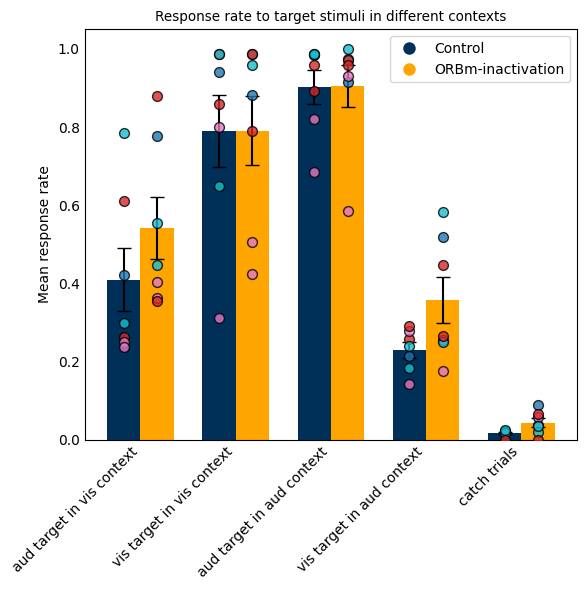

In [14]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Add mouse ID to muscimol_df_orbm
muscimol_df_orbm['mouse_id'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)

# Create color map for mouse IDs
unique_mice = muscimol_df_orbm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_orbm[muscimol_df_orbm['control']]
perturb_data = muscimol_df_orbm[muscimol_df_orbm['perturbation']]

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5)

# Add individual data points colored by mouse ID
for i, col in enumerate(columns):
    # Control points
    for idx, row in control_data.iterrows():
        ax.scatter(i - bar_width/2, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)
    
    # Perturbation points
    for idx, row in perturb_data.iterrows():
        ax.scatter(i + bar_width/2, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
          plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORBm-inactivation']
ax.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np

def check_session_gaps(df, max_days=4):
    """
    Check for sessions from the same mouse that are more than max_days apart.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with 'mouse_id' and 'date' columns
    max_days : int
        Maximum number of days allowed between sessions (default: 4)
    
    Returns:
    --------
    pandas.DataFrame with second session
    """
    # Sort by mouse_id and date
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    
    # Store problematic pairs
    gaps = []
    
    # Group by mouse_id
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        # Check consecutive sessions for this mouse
        for i in range(len(mouse_sessions) - 1):
            date1 = mouse_sessions.iloc[i]['date']
            date2 = mouse_sessions.iloc[i + 1]['date']
            session1 = mouse_sessions.iloc[i]['session_id']
            session2 = mouse_sessions.iloc[i + 1]['session_id']
            
            # Calculate days between sessions
            days_apart = abs((date2 - date1).days)
            
            if days_apart > max_days:
                gaps.append({
                    'mouse_id': mouse_id,
                    'session_1': session1,
                    'date_1': date1,
                    'session_2': session2,
                    'date_2': date2,
                    'days_apart': days_apart
                })
    
    gaps_df = pd.DataFrame(gaps)
    
    if len(gaps_df) > 0:
        print(f"\n⚠️ Found {len(gaps_df)} session pair(s) more than {max_days} days apart:\n")
        print(gaps_df.to_string(index=False))
    else:
        print(f"✓ All sessions are within {max_days} days of each other for the same mouse.")
    
    return gaps_df

# Check ORBm data
print("="*80)
print("CHECKING ORBm DATA:")
print("="*80)
orbm_gaps = check_session_gaps(muscimol_df_orbm, max_days=4)

# Check AId data
print("\n" + "="*80)
print("CHECKING AId DATA:")
print("="*80)
# aid_gaps = check_session_gaps(muscimol_df_aid, max_days=4)

# Summary statistics
print("\n" + "="*80)
print("SUMMARY:")
print("="*80)
print(f"ORBm: {len(orbm_gaps)} problematic session pairs")
# print(f"AId: {len(aid_gaps)} problematic session pairs")

CHECKING ORBm DATA:

⚠️ Found 3 session pair(s) more than 4 days apart:

mouse_id                                  session_1     date_1                                  session_2     date_2  days_apart
  807743 DynamicRoutingSession('807743_2025-11-04') 2025-11-04 DynamicRoutingSession('807743_2025-11-10') 2025-11-10           6
  813582 DynamicRoutingSession('813582_2025-12-09') 2025-12-09 DynamicRoutingSession('813582_2025-12-15') 2025-12-15           6
  824636 DynamicRoutingSession('824636_2026-01-13') 2026-01-13 DynamicRoutingSession('824636_2026-01-20') 2026-01-20           7

CHECKING AId DATA:

SUMMARY:
ORBm: 3 problematic session pairs


C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_29584\1596074605.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


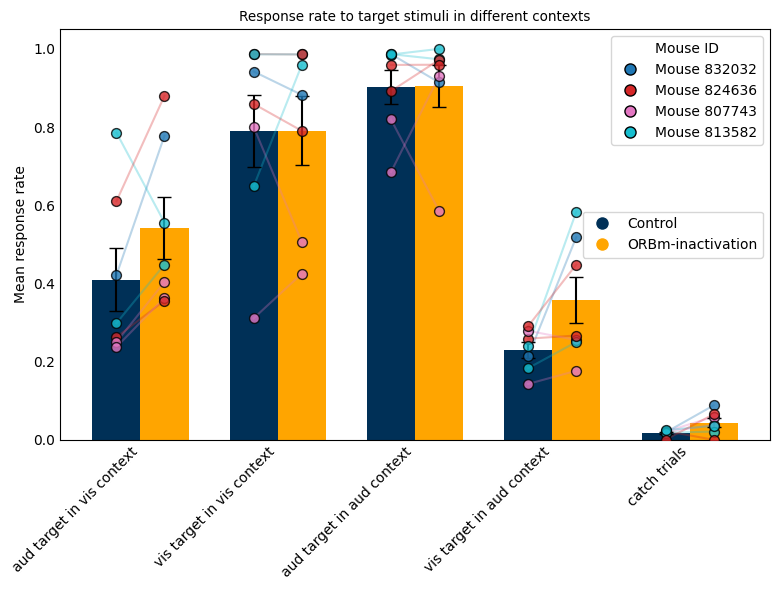

In [16]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_df_orbm['mouse_id'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)
muscimol_df_orbm['date'] = muscimol_df_orbm['session_id'].apply(extract_date_from_session)

# Create color map for mouse IDs
unique_mice = muscimol_df_orbm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_orbm[muscimol_df_orbm['control']].copy()
perturb_data = muscimol_df_orbm[muscimol_df_orbm['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points colored by mouse ID
for i, col in enumerate(columns):
    # Control points
    for idx, row in control_data.iterrows():
        ax.scatter(i - bar_width/2, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)
    
    # Perturbation points
    for idx, row in perturb_data.iterrows():
        ax.scatter(i + bar_width/2, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
#           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
# labels = ['Control', 'ORBm-inactivation']
# ax.legend(handles, labels, loc='lower left')
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='ORBm-inactivation')
]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine legends
first_legend = ax.legend(handles=condition_handles, loc='center right', frameon=True)
ax.add_artist(first_legend)
ax.legend(handles=mouse_handles, loc='upper right', frameon=True, title='Mouse ID')

plt.tight_layout()
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_38484\2100341208.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


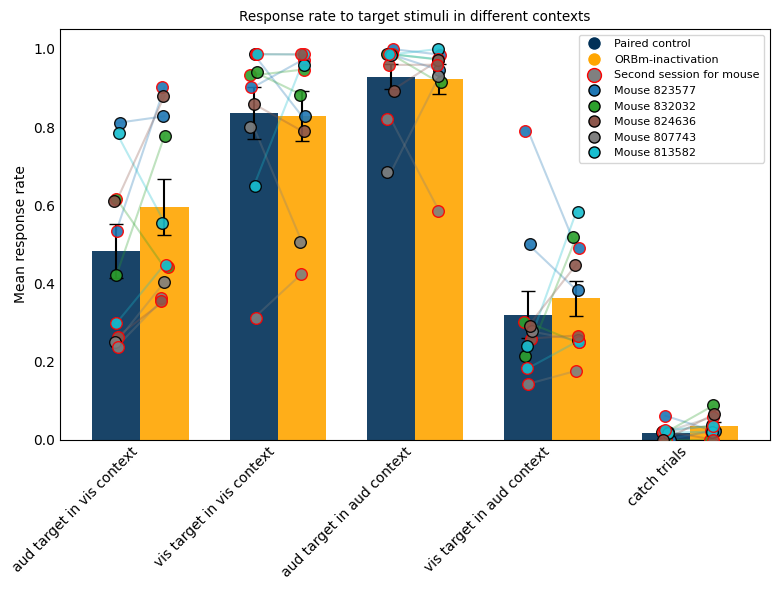

In [12]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_df_orbm['mouse_id'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)
muscimol_df_orbm['date'] = muscimol_df_orbm['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_orbm, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_df_orbm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_orbm[muscimol_df_orbm['control']].copy()
perturb_data = muscimol_df_orbm[muscimol_df_orbm['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='ORBm-inactivation')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='ORBm-inactivation')
]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Add gap indicator to legend
gap_handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Session >4 days after first')

# Combine legends
first_legend = ax.legend(handles=condition_handles + [gap_handle], loc='center right', frameon=True)
ax.add_artist(first_legend)
ax.legend(handles=mouse_handles, loc='upper right', frameon=True, title='Mouse ID')

plt(first_legend).tight_layout()


TypeError: 'module' object is not callable

In [ ]:
[0.92957746 0.58571429 1.         0.97333333 0.97183099 0.95945946]

## ORBm population effects


In [ ]:
from datetime import datetime

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_orbm['color_group'] = muscimol_df_orbm['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_orbm['date'] = muscimol_df_orbm['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_orbm = muscimol_df_orbm.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_orbm['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_aud_vis = []
for i in range(1, len(muscimol_df_orbm), 2):
    row1 = muscimol_df_orbm.loc[i - 1]
    row2 = muscimol_df_orbm.loc[i]
    if row1['control']:
        control_val = row1['auditory_target_in_visual_context']
        perturb_val = row2['auditory_target_in_visual_context']
        color_group = row1['color_group']
    else:
        control_val = row2['auditory_target_in_visual_context']
        perturb_val = row1['auditory_target_in_visual_context']
        color_group = row2['color_group']
    paired_data_aud_vis.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot
for x, y, group in paired_data_aud_vis:
    ax.scatter(x, y, color=color_map[group], alpha=0.8, linewidth=0.2)

# Mean cross
x_vals = [x for x, _, _ in paired_data_aud_vis]
y_vals = [y for _, y, _ in paired_data_aud_vis]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORBm Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Aud Target in Vis Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=color_map[group], markersize=8)
           for group in unique_groups]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORBmedial_aud_target_vis_context_unity_line_scatter", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_vis_aud = []
for i in range(1, len(muscimol_df_orbm), 2):
    row1 = muscimol_df_orbm.loc[i - 1]
    row2 = muscimol_df_orbm.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_auditory_context']
        perturb_val = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_auditory_context']
        perturb_val = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with yellow symbols and black outline
for x, y, group in paired_data_vis_aud:
    ax.scatter(x, y, facecolors='yellow', edgecolors='black', 
               alpha=0.8, linewidth=1.5, s=50)

# Mean cross
x_vals = [x for x, _, _ in paired_data_vis_aud]
y_vals = [y for _, y, _ in paired_data_vis_aud]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('ORB Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Vis Target in Aud Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='yellow', markeredgecolor='black', 
                      markeredgewidth=1.5, markersize=8)]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\ORBmedial_vis_target_aud_context_unity_line_scatter", dpi=300)
plt.show()

## AId data

In [17]:
muscimol_data_aid = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['807743_2025-11-06','807743_2025-11-07', '807743_2025-11-13', '807743_2025-11-14','813582_2025-12-11','813582_2025-12-12','813582_2025-12-18','813582_2025-12-19','824636_2026-01-15','824636_2026-01-16', '824636_2026-01-22', '824636_2026-01-23']
control = ['807743_2025-11-06', '807743_2025-11-13', '813582_2025-12-11', '813582_2025-12-18', '824636_2026-01-15','824636_2026-01-22']
perturbation = ['807743_2025-11-07', '807743_2025-11-14', '813582_2025-12-12', '813582_2025-12-19', '824636_2026-01-16', '824636_2026-01-23']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_aid.append(result)

# print(muscimol_data)
muscimol_df_aid = pd.DataFrame(muscimol_data_aid)
print(muscimol_df_aid)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                    session_id  control  perturbation  \
0   DynamicRoutingSession('807743_2025-11-06')     True         False   
1   DynamicRoutingSession('807743_2025-11-07')    False          True   
2   DynamicRoutingSession('807743_2025-11-13')     True         False   
3   DynamicRoutingSession('807743_2025-11-14')    False          True   
4   DynamicRoutingSession('813582_2025-12-11')     True         False   
5   DynamicRoutingSession('813582_2025-12-12')    False          True   
6   DynamicRoutingSession('813582_2025-12-18')     True         False   
7   DynamicRoutingSession('813582_2025-12-19')    False          True   
8   DynamicRoutingSession('824636_2026-01-15')     True         False   
9   DynamicRoutingSession('824636_2026-01-16')    False          True   
10  DynamicRoutingSession('824636_2026-01-22')     True         False   
11  DynamicRoutingSession('824636_2026-01-23')    False          True   

    vis_nontarget_vis_context_responses  aud_nonta

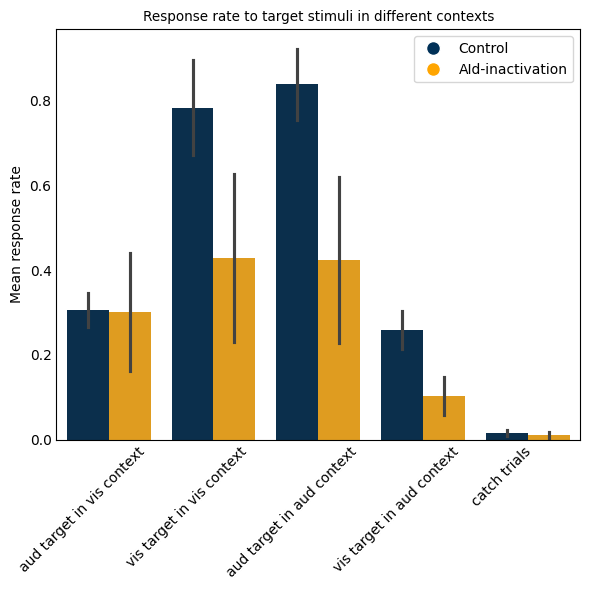

In [18]:
import seaborn as sns

muscimol_df_aid['session_id'] = muscimol_df_aid['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_aid[muscimol_df_aid['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_aid[muscimol_df_aid['control']]['visual_target_in_visual_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_aid[muscimol_df_aid['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_aid[muscimol_df_aid['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_aid[muscimol_df_aid['control']]['catch_trials'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'AId-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_12424\3497971068.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


TypeError: can only concatenate list (not "Line2D") to list

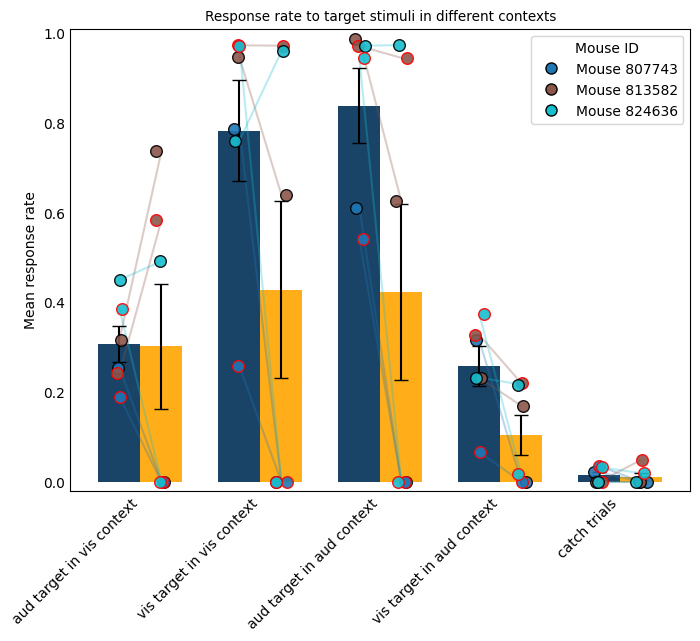

In [19]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_aid
muscimol_df_aid['mouse_id'] = muscimol_df_aid['session_id'].apply(extract_mouse_id)
muscimol_df_aid['date'] = muscimol_df_aid['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_aid, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_df_aid['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_aid[muscimol_df_aid['control']].copy()
perturb_data = muscimol_df_aid[muscimol_df_aid['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))
# ax.set_xlim(-0.05, 1.05)  # Adds 5% buffer on both sides
# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.05  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='AId-inactivation')
]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Add gap indicator to legend
gap_handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')

# Combine legends
first_legend = ax.legend(handles=condition_handles + [gap_handle], loc='center right', frameon=True)
# ax.add_artist(first_legend)
ax.legend(handles=mouse_handles, loc='upper right', frameon=True, title='Mouse ID')
# Axis labels and title
# ax.set_xlabel('ORBm Inactivation Response Rate', fontsize=10)
# ax.set_ylabel('Control Response Rate', fontsize=10)
# ax.set_title('Aud Target in Vis Context', fontsize=12)

# Add buffer to see points at 0
# ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.02, 1.01)  # Also add buffer to y-axis
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)
# Wilcoxon test
# wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
plt.tight_layout()
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_12424\36438133.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


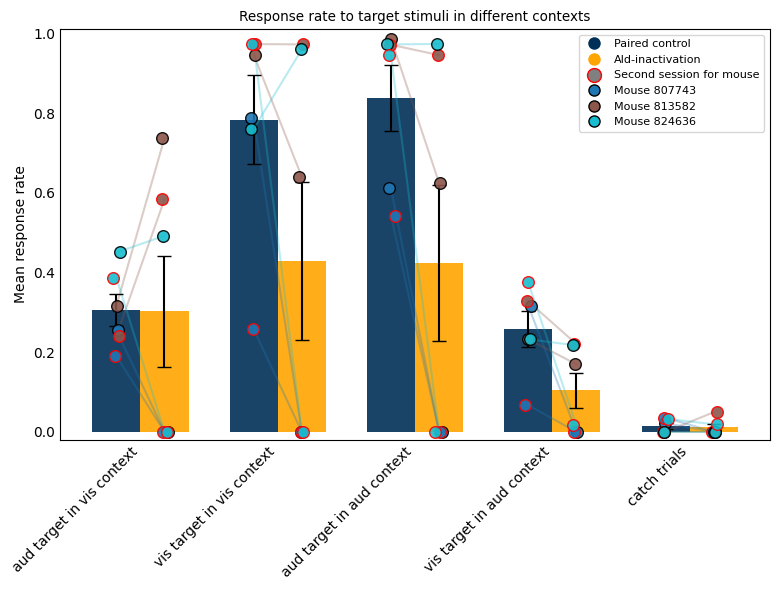

In [20]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_df_aid['mouse_id'] = muscimol_df_aid['session_id'].apply(extract_mouse_id)
muscimol_df_aid['date'] = muscimol_df_aid['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_aid, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_df_aid['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_aid[muscimol_df_aid['control']].copy()
perturb_data = muscimol_df_aid[muscimol_df_aid['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='AId-inactivation')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)
ax.set_ylim(-0.02, 1.01)
plt.tight_layout()
plt.show()

## AId population effects

In [ ]:
from datetime import datetime

result = dict(
    session_id=str(session.session_id) if hasattr(session, 'session_id') else str(session),
    # ...other fields...
)

#clean
import re

def extract_mouse_id(x):
    # Always convert to string
    s = str(x)
    # Try to extract the mouse ID using regex
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    # fallback: try splitting
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

muscimol_df_aid['color_group'] = muscimol_df_aid['session_id'].apply(extract_mouse_id)

# # Sort by date
muscimol_df_aid['date'] = muscimol_df_aid['session_id'].apply(
    lambda x: datetime.strptime(str(x).split('_')[1].split("'")[0], '%Y-%m-%d')
)
muscimol_df_aid = muscimol_df_aid.sort_values(by='date').reset_index(drop=True)

# unique colors bymouse ID
unique_groups = muscimol_df_aid['color_group'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_groups))
color_map = {group: colors(i) for i, group in enumerate(unique_groups)}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

# Assume muscimol_df_orb and previous cleaning steps are done

# --- Pair control and perturbation sessions for auditory target in visual context ---
paired_data_vis_aud = []
for i in range(1, len(muscimol_df_aid), 2):
    row1 = muscimol_df_aid.loc[i - 1]
    row2 = muscimol_df_aid.loc[i]
    if row1['control']:
        control_val = row1['visual_target_in_auditory_context']
        perturb_val = row2['visual_target_in_auditory_context']
        color_group = row1['color_group']
    else:
        control_val = row2['visual_target_in_auditory_context']
        perturb_val = row1['visual_target_in_auditory_context']
        color_group = row2['color_group']
    paired_data_vis_aud.append((perturb_val, control_val, color_group))

# --- Plot only one graph ---
fig, ax = plt.subplots(figsize=(3, 3))

# Scatter plot with yellow symbols and black outline
for x, y, group in paired_data_vis_aud:
    ax.scatter(x, y, facecolors='yellow', edgecolors='black', 
               alpha=0.8, linewidth=1.5, s=50)

# Mean cross
x_vals = [x for x, _, _ in paired_data_vis_aud]
y_vals = [y for _, y, _ in paired_data_vis_aud]
x_mean, y_mean = np.mean(x_vals), np.mean(y_vals)
x_std, y_std = np.std(x_vals), np.std(y_vals)
ax.plot([x_mean - x_std, x_mean + x_std], [y_mean, y_mean], color='black', lw=1.5)
ax.plot([x_mean, x_mean], [y_mean - y_std, y_mean + y_std], color='black', lw=1.5)

# Unity line
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

# Axis labels and title
ax.set_xlabel('AId Inactivation Response Rate', fontsize=10)
ax.set_ylabel('Control Response Rate', fontsize=10)
ax.set_title('Vis Target in Aud Context', fontsize=12)

# Wilcoxon test
wilcoxon_stat, p_val = wilcoxon(x_vals, y_vals)
ax.text(0.95, 0.05, f'wilcoxon stat = {wilcoxon_stat:.2f}\np = {p_val:.3g}',
        transform=ax.transAxes, fontsize=8,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='yellow', markeredgecolor='black', 
                      markeredgewidth=1.5, markersize=8)]
# ax.legend(handles, unique_groups, title="Mouse ID", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(r"Z:\vayle\muscimol_ORB_behavior_plots\AId_vis_target_aud_context_unity_line_scatter", dpi=300)
plt.show()

## ALM data

In [32]:
muscimol_data_alm = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['736208_2024-09-06', '736208_2024-08-30']
control = ['736208_2024-08-30']
perturbation = ['736208_2024-09-06']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_alm.append(result)

# print(muscimol_data)
muscimol_df_alm = pd.DataFrame(muscimol_data_alm)
print(muscimol_df_alm)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                   session_id  control  perturbation  \
0  DynamicRoutingSession('736208_2024-09-06')    False          True   
1  DynamicRoutingSession('736208_2024-08-30')     True         False   

   vis_nontarget_vis_context_responses  aud_nontarget_vis_context_responses  \
0                             0.035714                             0.000000   
1                             0.050000                             0.241379   

   vis_nontarget_aud_context_responses  aud_nontarget_aud_context_responses  \
0                             0.000000                             0.224138   
1                             0.050847                             0.636364   

   auditory_target_in_visual_context  visual_target_in_auditory_context  \
0                           0.362069                           0.293103   
1                           0.431034                           0.309091   

   visual_target_in_visual_context  auditory_target_in_auditory_context  \
0     

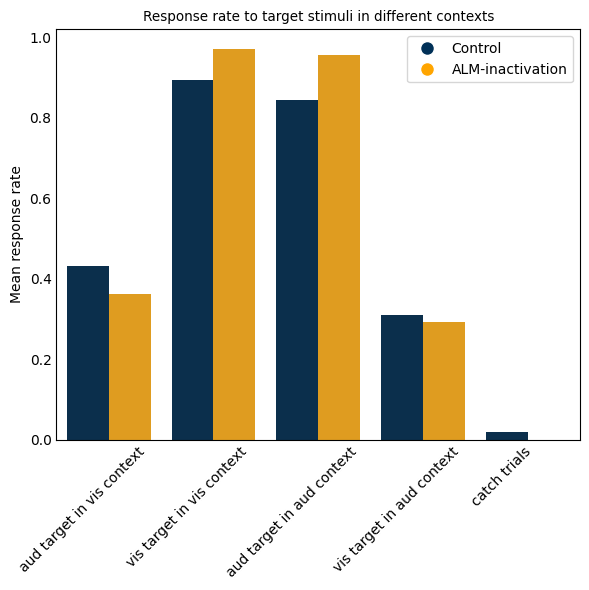

In [33]:
import seaborn as sns

muscimol_df_aid['session_id'] = muscimol_df_aid['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_alm[muscimol_df_alm['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_alm[muscimol_df_alm['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_alm[muscimol_df_alm['control']]['visual_target_in_visual_context'].values,
        muscimol_df_alm[muscimol_df_alm['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_alm[muscimol_df_alm['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_alm[muscimol_df_alm['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_alm[muscimol_df_alm['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_alm[muscimol_df_alm['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_alm[muscimol_df_alm['control']]['catch_trials'].values,
        muscimol_df_alm[muscimol_df_alm['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ALM-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_12424\909552261.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


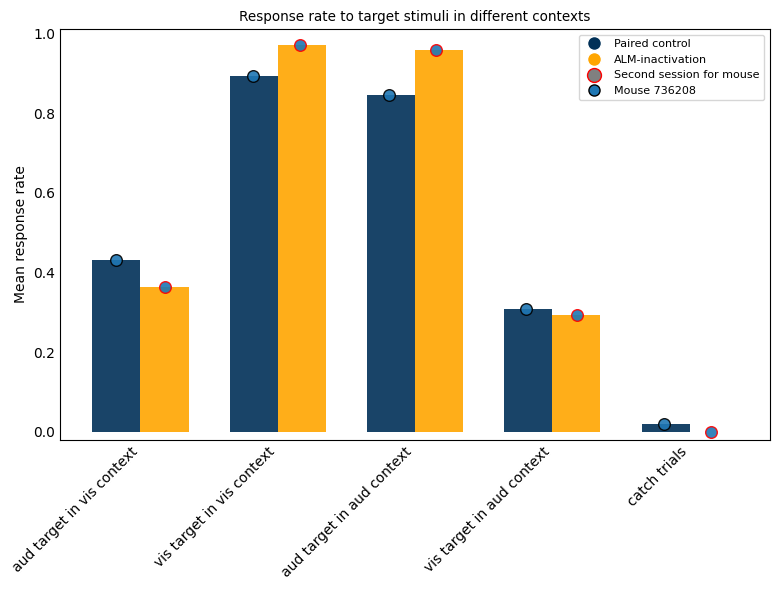

In [36]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_df_alm['mouse_id'] = muscimol_df_alm['session_id'].apply(extract_mouse_id)
muscimol_df_alm['date'] = muscimol_df_alm['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_alm, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_df_alm['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_alm[muscimol_df_alm['control']].copy()
perturb_data = muscimol_df_alm[muscimol_df_alm['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='ALM-inactivation')
]

# gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
#                         markeredgecolor='red', markersize=10, linewidth=2.5, 
#                         label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
# all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)
ax.set_ylim(-0.02, 1.01)
plt.tight_layout()
plt.show()

## ORBvl Conjugated data

In [39]:
muscimol_data_orbvl_conjugated = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['807742_2025-09-29','807742_2025-09-30', '807742_2025-10-06','807742_2025-10-07', '789937_2025-10-16','789937_2025-10-17','789937_2025-10-23','789937_2025-10-24', '805749_2025-10-23','805749_2025-10-24','805749_2025-10-30','805749_2025-10-31']
control = ['807742_2025-09-29', '807742_2025-10-06', '789937_2025-10-16', '789937_2025-10-23', '805749_2025-10-23', '805749_2025-10-30']
perturbation = ['807742_2025-09-30', '807742_2025-10-07', '789937_2025-10-17', '789937_2025-10-24','805749_2025-10-24','805749_2025-10-31']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_orbvl_conjugated.append(result)

# print(muscimol_data)
muscimol_data_orbvl_conjugated = pd.DataFrame(muscimol_data_orbvl_conjugated)
print(muscimol_data_orbvl_conjugated)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                    session_id  control  perturbation  \
0   DynamicRoutingSession('807742_2025-09-29')     True         False   
1   DynamicRoutingSession('807742_2025-09-30')    False          True   
2   DynamicRoutingSession('807742_2025-10-06')     True         False   
3   DynamicRoutingSession('807742_2025-10-07')    False          True   
4   DynamicRoutingSession('789937_2025-10-16')     True         False   
5   DynamicRoutingSession('789937_2025-10-17')    False          True   
6   DynamicRoutingSession('789937_2025-10-23')     True         False   
7   DynamicRoutingSession('789937_2025-10-24')    False          True   
8   DynamicRoutingSession('805749_2025-10-23')     True         False   
9   DynamicRoutingSession('805749_2025-10-24')    False          True   
10  DynamicRoutingSession('805749_2025-10-30')     True         False   
11  DynamicRoutingSession('805749_2025-10-31')    False          True   

    vis_nontarget_vis_context_responses  aud_nonta

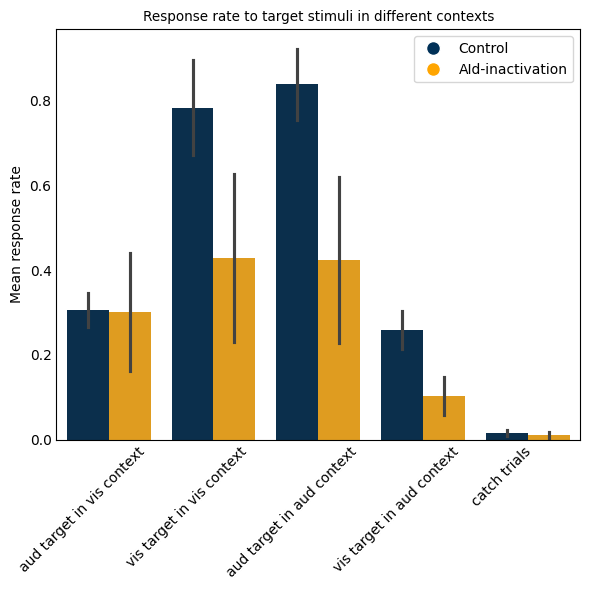

In [40]:
import seaborn as sns

muscimol_data_orbvl_conjugated['session_id'] = muscimol_data_orbvl_conjugated['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_aid[muscimol_df_aid['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_aid[muscimol_df_aid['control']]['visual_target_in_visual_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_aid[muscimol_df_aid['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_aid[muscimol_df_aid['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_aid[muscimol_df_aid['control']]['catch_trials'].values,
        muscimol_df_aid[muscimol_df_aid['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_values_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'AId-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_12424\3668628814.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


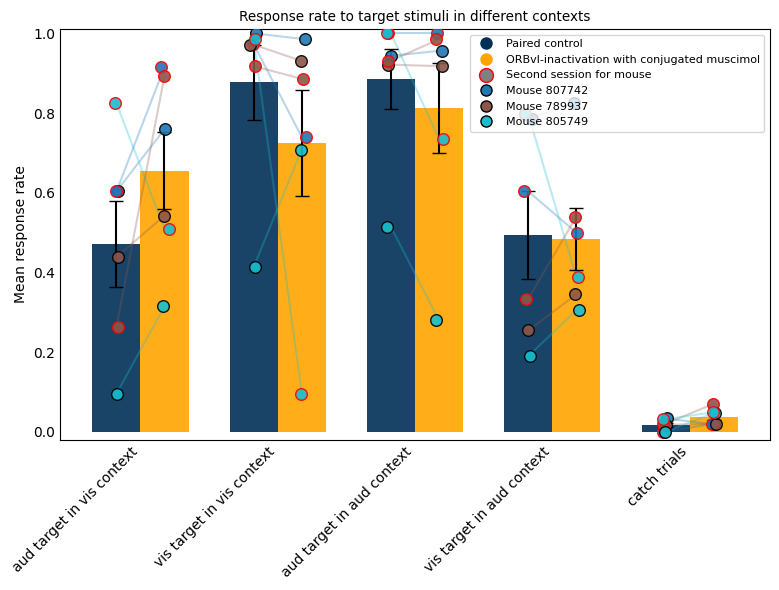

In [41]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_data_orbvl_conjugated['mouse_id'] = muscimol_data_orbvl_conjugated['session_id'].apply(extract_mouse_id)
muscimol_data_orbvl_conjugated['date'] = muscimol_data_orbvl_conjugated['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_data_orbvl_conjugated, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_data_orbvl_conjugated['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_data_orbvl_conjugated[muscimol_data_orbvl_conjugated['control']].copy()
perturb_data = muscimol_data_orbvl_conjugated[muscimol_data_orbvl_conjugated['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='ORBvl-inactivation with conjugated muscimol')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)
ax.set_ylim(-0.02, 1.01)
plt.tight_layout()
plt.show()

## Anterior Striatum

In [20]:
reload npc_sessions

SyntaxError: invalid syntax (1547940275.py, line 1)

In [3]:
muscimol_data_ant_str = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['823577_2026-03-12','823577_2026-03-13','832032_2026-03-12','832032_2026-03-13','832032_2026-03-05', '832032_2026-03-06','780116_2025-08-07','780116_2025-08-08','780116_2025-08-14', '780116_2025-08-15']
control = ['823577_2026-03-12','832032_2026-03-12','832032_2026-03-05','780116_2025-08-07', '780116_2025-08-14']
perturbation = ['823577_2026-03-13','832032_2026-03-13','832032_2026-03-06','780116_2025-08-08', '780116_2025-08-15']

vis_first_perturbations = []
aud_first_perturbations=[]
# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_ant_str.append(result)

# print(muscimol_data)
muscimol_data_ant_str = pd.DataFrame(muscimol_data_ant_str)
print(muscimol_data_ant_str)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                   session_id  control  perturbation  \
0  DynamicRoutingSession('823577_2026-03-12')     True         False   
1  DynamicRoutingSession('823577_2026-03-13')    False          True   
2  DynamicRoutingSession('832032_2026-03-12')     True         False   
3  DynamicRoutingSession('832032_2026-03-13')    False          True   
4  DynamicRoutingSession('832032_2026-03-05')     True         False   
5  DynamicRoutingSession('832032_2026-03-06')    False          True   
6  DynamicRoutingSession('780116_2025-08-07')     True         False   
7  DynamicRoutingSession('780116_2025-08-08')    False          True   
8  DynamicRoutingSession('780116_2025-08-14')     True         False   
9  DynamicRoutingSession('780116_2025-08-15')    False          True   

   vis_nontarget_vis_context_responses  aud_nontarget_vis_context_responses  \
0                             0.035714                             0.254545   
1                             0.087719           

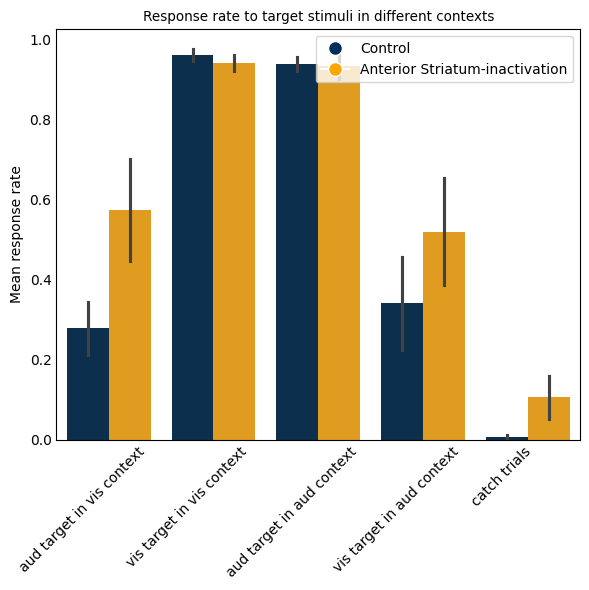

In [5]:
import seaborn as sns

muscimol_data_ant_str['session_id'] = muscimol_data_ant_str['session_id'].astype(str)

avg_ant_str = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_data_ant_str[muscimol_data_ant_str['control']]['auditory_target_in_visual_context'].values,
        muscimol_data_ant_str[muscimol_data_ant_str['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_data_ant_str[muscimol_data_ant_str['control']]['visual_target_in_visual_context'].values,
        muscimol_data_ant_str[muscimol_data_ant_str['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_data_ant_str[muscimol_data_ant_str['control']]['auditory_target_in_auditory_context'].values,
        muscimol_data_ant_str[muscimol_data_ant_str['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_data_ant_str[muscimol_data_ant_str['control']]['visual_target_in_auditory_context'].values,
        muscimol_data_ant_str[muscimol_data_ant_str['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_data_ant_str[muscimol_data_ant_str['control']]['catch_trials'].values,
        muscimol_data_ant_str[muscimol_data_ant_str['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_ant_str_df = pd.DataFrame(avg_ant_str)

avg_ant_str_melted = avg_ant_str_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_ant_str_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'Anterior Striatum-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_38484\1604671252.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


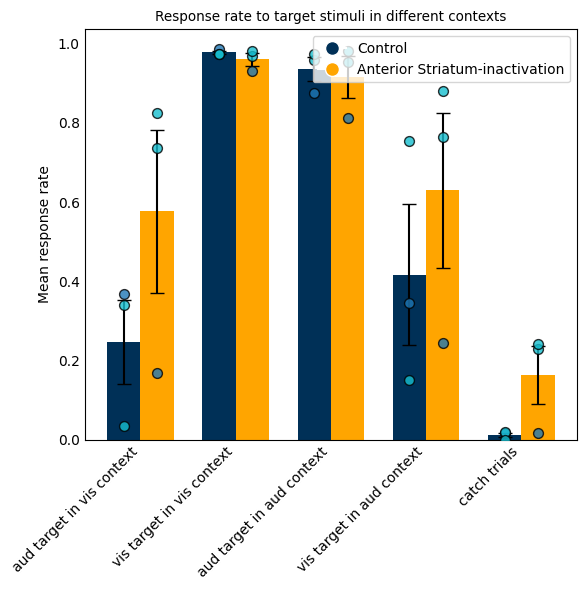

In [5]:

import re

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Add mouse ID to muscimol_data_ant_str
muscimol_data_ant_str['mouse_id'] = muscimol_data_ant_str['session_id'].apply(extract_mouse_id)

# Create color map for mouse IDs
unique_mice = muscimol_data_ant_str['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_data_ant_str[muscimol_data_ant_str['control']]
perturb_data = muscimol_data_ant_str[muscimol_data_ant_str['perturbation']]

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(6, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5)

# Add individual data points colored by mouse ID
for i, col in enumerate(columns):
    # Control points
    for idx, row in control_data.iterrows():
        ax.scatter(i - bar_width/2, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)
    
    # Perturbation points
    for idx, row in perturb_data.iterrows():
        ax.scatter(i + bar_width/2, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='black', s=50, alpha=0.8, linewidth=1, zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
          plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'Anterior Striatum-inactivation']
ax.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_31652\3500915486.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


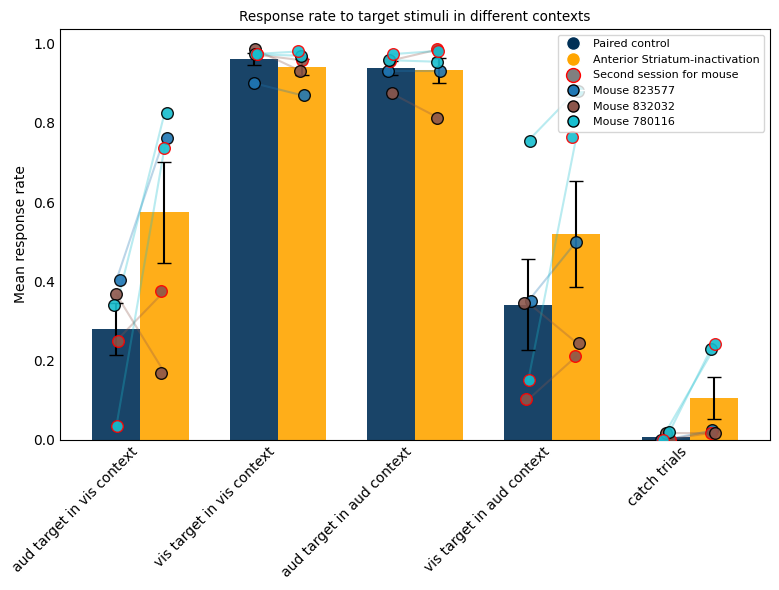

In [7]:

from datetime import timedelta
import re

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_orbm
muscimol_data_ant_str['mouse_id'] = muscimol_data_ant_str['session_id'].apply(extract_mouse_id)
muscimol_data_ant_str['date'] = muscimol_data_ant_str['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_data_ant_str, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_data_ant_str['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_data_ant_str[muscimol_data_ant_str['control']].copy()
perturb_data = muscimol_data_ant_str[muscimol_data_ant_str['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='Anterior Striatum-inactivation')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
path  = r"Z:\PilotEphys\Task 2 pilot"

In [3]:
import os
from pathlib import Path

path = r"Z:\PilotEphys\Task 2 pilot"

# Method 1: Using os.listdir
xml_files = [f for f in os.listdir(path) if f.endswith('.xml')]
for xml_file in xml_files:
    full_path = os.path.join(path, xml_file)
    print(f"Found XML file: {full_path}")
    # Do something with the file here

# Method 2: Using pathlib (recommended)
path_obj = Path(path)
for xml_file in path_obj.glob('*.xml'):
    print(f"Found XML file: {xml_file}")
    # Do something with the file here

# Method 3: Recursive search (searches subdirectories too)
for xml_file in path_obj.rglob('*.xml'):
    print(f"Found XML file: {xml_file}")
    # Do something with the file here

Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_743199_20241203_surface_channels\Record Node 104\settings.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_743199_20241203_surface_channels\Record Node 108\settings.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_366122_20250109\DRpilot_366122_20250109\Record Node 104\settings_2.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_366122_20250109\DRpilot_366122_20250109\Record Node 108\settings_2.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_743199_20241205_surface_channels\Record Node 104\settings.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_743199_20241205_surface_channels\Record Node 108\settings.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_746439_20250128\DRpilot_746439_20250128\Record Node 104\settings.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_746439_20250128\DRpilot_746439_20250128\Record Node 108\settings.xml
Found XML file: Z:\PilotEphys\Task 2 pilot\DRpilot_649943_202302

KeyboardInterrupt: 

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import datetime
import pandas as pd

path = r"Z:\PilotEphys\Task 2 pilot"
serial_numbers_to_find = [
    '22175714742', '22175714252', '19192715401', '23328308761', 
    '18005707091', '18005116091', '19192723682', '18005108082', 
    '19192722651', '18194808771', '18005116652'
]

serial_earliest_dates = {serial: None for serial in serial_numbers_to_find}
path_obj = Path(path)

print("="*80)
print("EXTRACTING SERIAL NUMBERS FROM CUSTOM_PROBE_NAMES")
print("="*80)

for xml_file in path_obj.glob('**/settings.xml'):  # Search in subdirectories too
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Parse date
        xml_date = None
        date_elem = root.find('.//DATE')
        if date_elem is not None and date_elem.text:
            try:
                xml_date = datetime.strptime(date_elem.text.strip(), '%d %b %Y %H:%M:%S')
            except ValueError:
                xml_date = datetime.fromtimestamp(xml_file.stat().st_mtime)
        else:
            xml_date = datetime.fromtimestamp(xml_file.stat().st_mtime)
        
        # Find CUSTOM_PROBE_NAMES element
        custom_names = root.find('.//CUSTOM_PROBE_NAMES')
        
        if custom_names is not None:
            # Get all attributes (they start with 'SN')
            for attr_name, probe_name in custom_names.attrib.items():
                if attr_name.startswith('SN'):
                    # Extract serial number (remove 'SN' prefix)
                    serial = attr_name[2:]  # Remove 'SN' prefix
                    
                    if serial in serial_numbers_to_find:
                        if serial_earliest_dates[serial] is None or xml_date < serial_earliest_dates[serial]:
                            serial_earliest_dates[serial] = xml_date
                            print(f"\n✓ Found {serial} (Probe {probe_name}) in {xml_file.parent.name}")
                            print(f"  Date: {xml_date.strftime('%Y-%m-%d %H:%M:%S')}")
                            print(f"  Full path: {xml_file}")
                    
    except Exception as e:
        print(f"Error processing {xml_file}: {e}")

# Summary
print("\n" + "="*80)
print("SUMMARY: EARLIEST RECORDED DATE FOR EACH SERIAL NUMBER")
print("="*80)

results = []
for serial, date in serial_earliest_dates.items():
    results.append({
        'Serial Number': serial,
        'Earliest Date': date.strftime('%Y-%m-%d %H:%M:%S') if date else 'NOT FOUND',
        'Days Ago': (datetime.now() - date).days if date else None
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

found_count = sum(1 for date in serial_earliest_dates.values() if date is not None)
print(f"\n{found_count}/{len(serial_numbers_to_find)} serial numbers found")

# Show all serial numbers found across all files
print("\n" + "="*80)
print("ALL SERIAL NUMBERS FOUND IN XML FILES")
print("="*80)

all_serials = set()
for xml_file in path_obj.glob('**/settings.xml'):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        custom_names = root.find('.//CUSTOM_PROBE_NAMES')
        if custom_names is not None:
            for attr_name in custom_names.attrib.keys():
                if attr_name.startswith('SN'):
                    all_serials.add(attr_name[2:])
    except:
        pass

print(f"Unique serial numbers in dataset: {sorted(all_serials)}")
print(f"Total unique probes: {len(all_serials)}")

EXTRACTING SERIAL NUMBERS FROM CUSTOM_PROBE_NAMES


KeyboardInterrupt: 

In [4]:
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import datetime
import pandas as pd

path = r"Z:\PilotEphys\Task 2 pilot"
serial_numbers_to_find = [
    '22175714742', '22175714252', '19192715401', '23328308761', 
    '18005707091', '18005116091', '19192723682', '18005108082', 
    '19192722651', '18194808771', '18005116652'
]

# Dictionary to store earliest date AND filename for each serial number
serial_earliest_info = {serial: {'date': None, 'file': None, 'probe_name': None} for serial in serial_numbers_to_find}
path_obj = Path(path)

print("="*80)
print("SEARCHING FOR SERIAL NUMBERS...")
print("="*80)

# First pass: find ALL occurrences and determine earliest dates
for xml_file in path_obj.glob('**/settings.xml'):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Parse date
        xml_date = None
        date_elem = root.find('.//DATE')
        if date_elem is not None and date_elem.text:
            try:
                xml_date = datetime.strptime(date_elem.text.strip(), '%d %b %Y %H:%M:%S')
            except ValueError:
                xml_date = datetime.fromtimestamp(xml_file.stat().st_mtime)
        else:
            xml_date = datetime.fromtimestamp(xml_file.stat().st_mtime)
        
        # Find CUSTOM_PROBE_NAMES element
        custom_names = root.find('.//CUSTOM_PROBE_NAMES')
        
        if custom_names is not None:
            for attr_name, probe_name in custom_names.attrib.items():
                if attr_name.startswith('SN'):
                    serial = attr_name[2:]
                    
                    if serial in serial_numbers_to_find:
                        # Update if this is the earliest date for this serial number
                        if serial_earliest_info[serial]['date'] is None or xml_date < serial_earliest_info[serial]['date']:
                            serial_earliest_info[serial]['date'] = xml_date
                            serial_earliest_info[serial]['file'] = xml_file
                            serial_earliest_info[serial]['probe_name'] = probe_name
                    
    except Exception as e:
        print(f"Error processing {xml_file}: {e}")

# Print ONLY the earliest occurrences
print("\n" + "="*80)
print("EARLIEST OCCURRENCE OF EACH SERIAL NUMBER:")
print("="*80)

for serial, info in serial_earliest_info.items():
    if info['date'] is not None:
        print(f"\n✓ Serial: {serial}")
        print(f"  Probe Name: {info['probe_name']}")
        print(f"  Earliest Date: {info['date'].strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"  Session: {info['file'].parent.name}")
        print(f"  Full Path: {info['file']}")

# Summary table
print("\n" + "="*80)
print("SUMMARY:")
print("="*80)

results = []
for serial, info in serial_earliest_info.items():
    results.append({
        'Serial Number': serial,
        'Earliest Date': info['date'].strftime('%Y-%m-%d') if info['date'] else 'NOT FOUND',
        'Probe Name': info['probe_name'] if info['probe_name'] else 'N/A',
        'Session': info['file'].parent.name if info['file'] else 'N/A'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

found_count = sum(1 for info in serial_earliest_info.values() if info['date'] is not None)
print(f"\n{found_count}/{len(serial_numbers_to_find)} serial numbers found")

SEARCHING FOR SERIAL NUMBERS...

EARLIEST OCCURRENCE OF EACH SERIAL NUMBER:

✓ Serial: 22175714742
  Probe Name: ProbeE
  Earliest Date: 2025-12-04 12:45:36
  Session: Record Node 101
  Full Path: Z:\PilotEphys\Task 2 pilot\DRpilot_813586_20251204\DRpilot_813586_20251204\Record Node 101\settings.xml

✓ Serial: 22175714252
  Probe Name: ProbeB
  Earliest Date: 2025-08-21 12:00:37
  Session: Record Node 104
  Full Path: Z:\PilotEphys\Task 2 pilot\DRpilot_795555_20250821\DRpilot_795555_20250821\Record Node 104\settings.xml

✓ Serial: 19192715401
  Probe Name: ProbeB
  Earliest Date: 2024-04-15 12:48:37
  Session: Record Node 101
  Full Path: Z:\PilotEphys\Task 2 pilot\DRpilot_699847_20240415\DRpilot_699847_20240415\Record Node 101\settings.xml

✓ Serial: 18005116091
  Probe Name: ProbeF
  Earliest Date: 2026-01-12 16:06:50
  Session: Record Node 101
  Full Path: Z:\PilotEphys\Task 2 pilot\DRpilot_822061_20260112\DRpilot_822061_20260112\Record Node 101\settings.xml

✓ Serial: 19192723682
 

In [7]:
import xml.etree.ElementTree as ET
from pathlib import Path
from datetime import datetime

path = r"Z:\PilotEphys\Task 2 pilot"
target_serial = '18005707091'
path_obj = Path(path)

print("="*80)
print(f"DEBUGGING: SEARCHING FOR {target_serial}")
print("="*80)

# Search for ANY occurrence of this number in ANY form
found_count = 0
partial_matches = []

for xml_file in path_obj.glob('**/settings.xml'):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Check CUSTOM_PROBE_NAMES
        custom_names = root.find('.//CUSTOM_PROBE_NAMES')
        if custom_names is not None:
            for attr_name, probe_name in custom_names.attrib.items():
                # Extract the serial number
                if attr_name.startswith('SN'):
                    serial = attr_name[2:]
                    
                    # Exact match
                    if serial == target_serial:
                        found_count += 1
                        date_elem = root.find('.//DATE')
                        xml_date = date_elem.text if date_elem is not None else 'Unknown'
                        print(f"\n✓ EXACT MATCH in {xml_file.parent.name}")
                        print(f"  Attribute: {attr_name}")
                        print(f"  Probe Name: {probe_name}")
                        print(f"  Date: {xml_date}")
                        print(f"  Path: {xml_file}")
                    
                    # Partial match (in case there's a typo)
                    elif target_serial in serial or serial in target_serial:
                        partial_matches.append({
                            'file': xml_file.parent.name,
                            'serial': serial,
                            'probe_name': probe_name,
                            'attr': attr_name
                        })
                        
    except Exception as e:
        continue

print(f"\n{'='*80}")
print(f"RESULTS: Found {found_count} exact matches")

if partial_matches:
    print(f"\nPartial matches found ({len(partial_matches)}):")
    for match in partial_matches:
        print(f"  {match['serial']} in {match['file']} (Probe: {match['probe_name']})")

if found_count == 0 and not partial_matches:
    print(f"\n⚠️ Serial {target_serial} was NOT found in any XML files")
    print("\nPossible reasons:")
    print("1. This probe was never used in sessions under this path")
    print("2. The serial number has a typo")
    print("3. The probe data wasn't saved properly")
    print("4. The XML files don't contain CUSTOM_PROBE_NAMES for this session")

# Show all unique serial numbers that DO exist
print(f"\n{'='*80}")
print("ALL SERIAL NUMBERS IN DATASET:")
print("="*80)

all_serials = set()
for xml_file in path_obj.glob('**/settings.xml'):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        custom_names = root.find('.//CUSTOM_PROBE_NAMES')
        if custom_names is not None:
            for attr_name in custom_names.attrib.keys():
                if attr_name.startswith('SN'):
                    all_serials.add(attr_name[2:])
    except:
        pass

sorted_serials = sorted(all_serials)
print(f"\nFound {len(sorted_serials)} unique probes:")
for serial in sorted_serials:
    print(f"  {serial}")

DEBUGGING: SEARCHING FOR 18005707091

RESULTS: Found 0 exact matches

⚠️ Serial 18005707091 was NOT found in any XML files

Possible reasons:
1. This probe was never used in sessions under this path
2. The serial number has a typo
3. The probe data wasn't saved properly
4. The XML files don't contain CUSTOM_PROBE_NAMES for this session

ALL SERIAL NUMBERS IN DATASET:

Found 41 unique probes:
  17131307152
  17131307591
  17131309501
  17216703422
  18005102491
  18005106182
  18005107091
  18005108082
  18005110671
  18005114452
  18005114552
  18005116091
  18005116652
  18005118352
  18005118602
  18005120322
  18005121302
  18005123131
  18194808771
  18194810652
  19192715131
  19192715251
  19192715321
  19192715322
  19192715401
  19192722651
  19192722691
  19192723682
  20097906812
  20097906862
  20097909142
  22175714252
  22175714742
  22175714802
  22175718052
  22175718082
  22175718152
  22175718192
  22175718682
  22175718812
  22175721871


In [6]:
import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd

path = r"Z:\PilotEphys\Task 2 pilot"
serial_numbers_to_find = [
    '22175714742', '22175714252', '19192715401', '23328308761', 
    '18005707091', '18005116091', '19192723682', '18005108082', 
    '19192722651', '18194808771', '18005116652'
]

# Dictionary to count occurrences
serial_counts = {serial: 0 for serial in serial_numbers_to_find}
path_obj = Path(path)

print("="*80)
print("COUNTING XML FILES CONTAINING EACH SERIAL NUMBER")
print("="*80)

# Count occurrences
for xml_file in path_obj.glob('**/settings.xml'):
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        
        # Find CUSTOM_PROBE_NAMES element
        custom_names = root.find('.//CUSTOM_PROBE_NAMES')
        
        if custom_names is not None:
            for attr_name in custom_names.attrib.keys():
                if attr_name.startswith('SN'):
                    serial = attr_name[2:]
                    
                    if serial in serial_numbers_to_find:
                        serial_counts[serial] += 1
                    
    except Exception as e:
        continue

# Create summary table
results = []
for serial, count in serial_counts.items():
    results.append({
        'Serial Number': serial,
        'XML Files Found': count,
        'Status': '✓ Found' if count > 0 else '✗ NOT FOUND'
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('XML Files Found', ascending=False)

print("\n" + results_df.to_string(index=False))

# Summary statistics
found_serials = sum(1 for count in serial_counts.values() if count > 0)
total_files = sum(serial_counts.values())

print("\n" + "="*80)
print("SUMMARY:")
print(f"  Serial numbers found: {found_serials}/{len(serial_numbers_to_find)}")
print(f"  Total XML files with these serials: {total_files}")
print("="*80)

COUNTING XML FILES CONTAINING EACH SERIAL NUMBER

Serial Number  XML Files Found      Status
  19192723682              150     ✓ Found
  19192722651              150     ✓ Found
  22175714252              125     ✓ Found
  18005116652              122     ✓ Found
  18194808771               83     ✓ Found
  19192715401               62     ✓ Found
  22175714742               45     ✓ Found
  18005116091               26     ✓ Found
  18005108082               14     ✓ Found
  23328308761                0 ✗ NOT FOUND
  18005707091                0 ✗ NOT FOUND

SUMMARY:
  Serial numbers found: 9/11
  Total XML files with these serials: 777


## DMS data

In [3]:
muscimol_data_dms = []

#def(mouse, perturbation or control)
session_ids = ['717473_2024-09-16', '717473_2024-09-17', '717473_2024-09-18', '717473_2024-09-19', '759435_2025-05-29', '759435_2025-05-30','759435_2025-05-23','759435_2025-05-22','772657_2025-02-27','772657_2025-02-28','774916_2025-03-27', '774916_2025-03-28', '780327_2025-03-31','780327_2025-04-01','774916_2025-04-03','774916_2025-04-04', '780327_2025-04-07', '780327_2025-04-08']
control = ['717473_2024-09-16','717473_2024-09-18','759435_2025-05-22', '759435_2025-05-29','772657_2025-02-27','774916_2025-03-27', '780327_2025-03-31', '774916_2025-04-03', '780327_2025-04-07']
perturbation = ['717473_2024-09-17', '717473_2024-09-19','759435_2025-05-30', '759435_2025-05-23','772657_2025-02-28','774916_2025-03-28', '780327_2025-04-01', '774916_2025-04-04', '780327_2025-04-08']

ori_first = []
amn_first=[]

for session in session_ids:
    session = npc_sessions.Session(session)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))


    # quiescent trials
    # quiescent_responses = session.trials[:].query(
    #         'is_response == True & is_catch == True'
    #   )
    # all_catch = session.trials[:].query(
    #         'is_catch == True'
    #   )
    # catch_trials = (len(catch_responses)/(len(all_catch)))
    result = dict(
                    session_id=session,
                    control = False,
                    perturbation = False,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context =auditory_target_in_auditory_context,
                    catch_trials=catch_trials
                    )
    
    if session in perturbation:
            result['perturbation'] = True
    else:
            result['control'] = True

    muscimol_data_dms.append(result)

# print(muscimol_data)
muscimol_df_dms = pd.DataFrame(muscimol_data_dms)
print(muscimol_df_dms)

                                    session_id  control  perturbation  \
0   DynamicRoutingSession('717473_2024-09-16')     True         False   
1   DynamicRoutingSession('717473_2024-09-17')    False          True   
2   DynamicRoutingSession('717473_2024-09-18')     True         False   
3   DynamicRoutingSession('717473_2024-09-19')    False          True   
4   DynamicRoutingSession('759435_2025-05-29')     True         False   
5   DynamicRoutingSession('759435_2025-05-30')    False          True   
6   DynamicRoutingSession('759435_2025-05-23')    False          True   
7   DynamicRoutingSession('759435_2025-05-22')     True         False   
8   DynamicRoutingSession('772657_2025-02-27')     True         False   
9   DynamicRoutingSession('772657_2025-02-28')    False          True   
10  DynamicRoutingSession('774916_2025-03-27')     True         False   
11  DynamicRoutingSession('774916_2025-03-28')    False          True   
12  DynamicRoutingSession('780327_2025-03-31')     

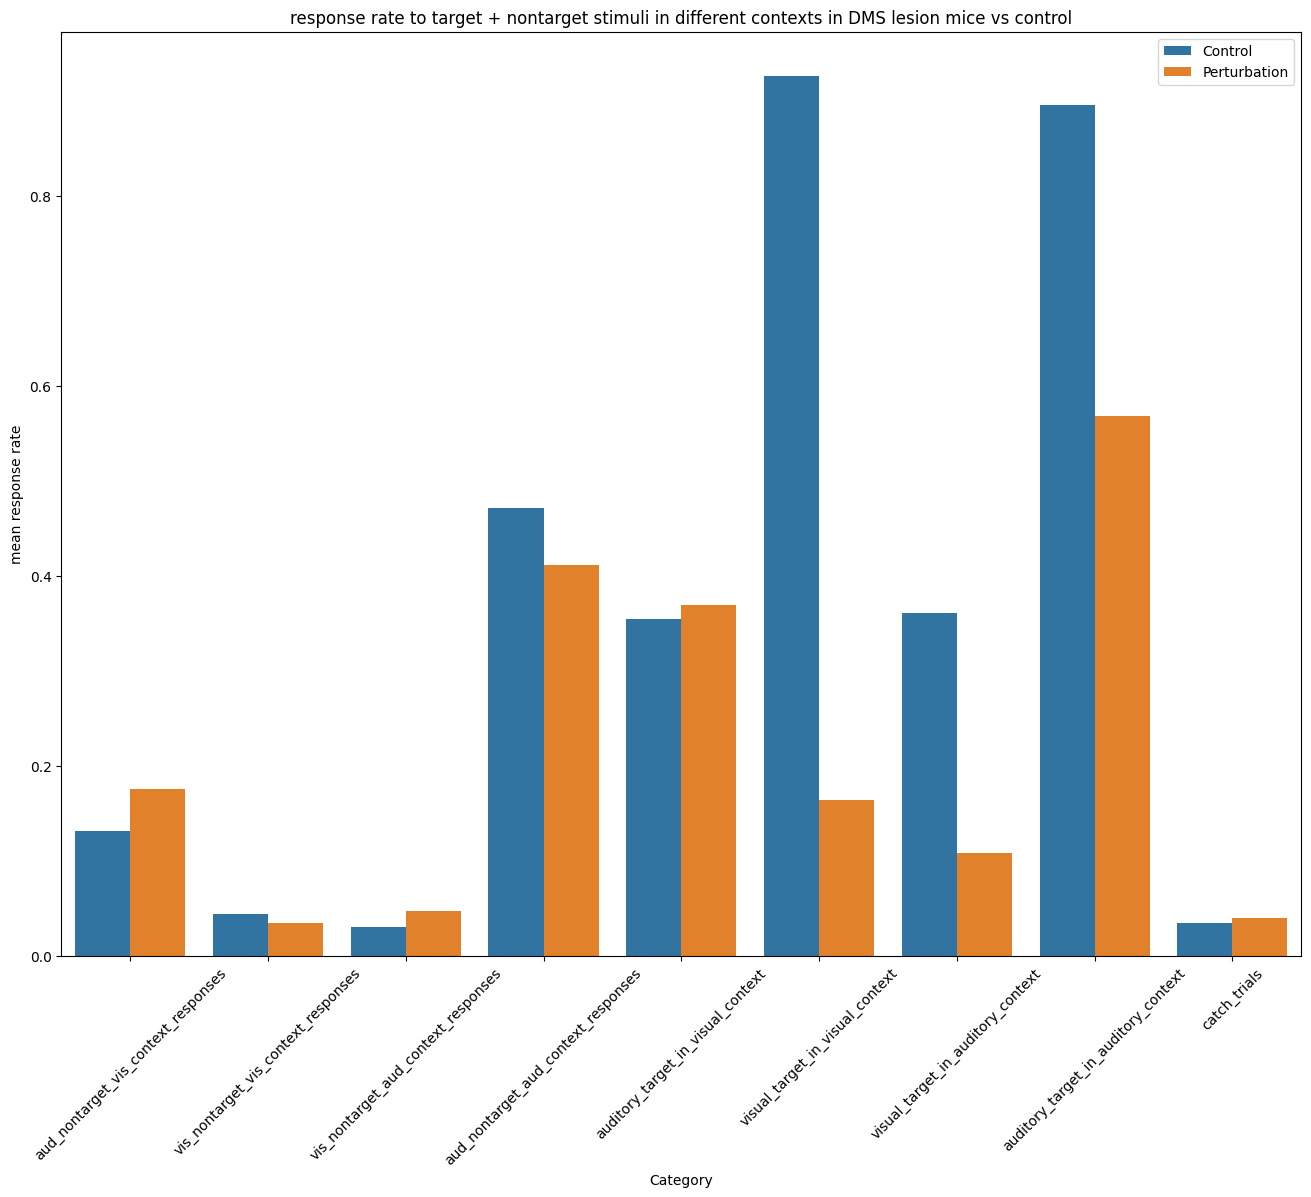

<Figure size 640x480 with 0 Axes>

In [4]:
import seaborn as sns

muscimol_df_dms['session_id'] = muscimol_df_dms['session_id'].astype(str)

avg_values = {
    'Condition': ['Control', 'Perturbation'],

    'aud_nontarget_vis_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['aud_nontarget_vis_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['aud_nontarget_vis_context_responses'].mean()
    ],

    'vis_nontarget_vis_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_vis_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_vis_context_responses'].mean()
        ],

    'vis_nontarget_aud_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['vis_nontarget_aud_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['vis_nontarget_aud_context_responses'].mean()
        ],
    'aud_nontarget_aud_context_responses': [
    muscimol_df_dms[muscimol_df_dms['control']]['aud_nontarget_aud_context_responses'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['aud_nontarget_aud_context_responses'].mean()
          ],
          
    'auditory_target_in_visual_context': [
    muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_visual_context'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_visual_context'].mean()
              ],

     'visual_target_in_visual_context':[
        muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_visual_context'].mean(),
        muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_visual_context'].mean()
    ],

    'visual_target_in_auditory_context': [
    muscimol_df_dms[muscimol_df_dms['control']]['visual_target_in_auditory_context'].mean(),
    muscimol_df_dms[muscimol_df_dms['perturbation']]['visual_target_in_auditory_context'].mean()
                  ],

    'auditory_target_in_auditory_context':[
        muscimol_df_dms[muscimol_df_dms['control']]['auditory_target_in_auditory_context'].mean(),
        muscimol_df_dms[muscimol_df_dms['perturbation']]['auditory_target_in_auditory_context'].mean()
    ],
 'catch_trials':[
        muscimol_df_dms[muscimol_df_dms['control']]['catch_trials'].mean(),
        muscimol_df_dms[muscimol_df_dms['perturbation']]['catch_trials'].mean()
    ]
#  'Total Vis Target Aud Context':[
#         muscimol_df_orb[muscimol_df_orb['control']]['total_vis_rewarded_responses_in_aud_context'].mean(),
#         muscimol_df_orb[muscimol_df_orb['perturbation']]['total_vis_rewarded_responses_in_aud_context'].mean()
#     ]

}

# Create a DataFrame from the dictionary
avg_values_df = pd.DataFrame(avg_values)

avg_values_melted_dms = avg_values_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(16, 12))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', data=avg_values_melted_dms)
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('mean response rate')
plt.title('response rate to target + nontarget stimuli in different contexts in DMS lesion mice vs control')
plt.legend(loc='upper right')
plt.show()

# Show the plot
plt.tight_layout()
plt.show()

C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_10916\3663407698.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


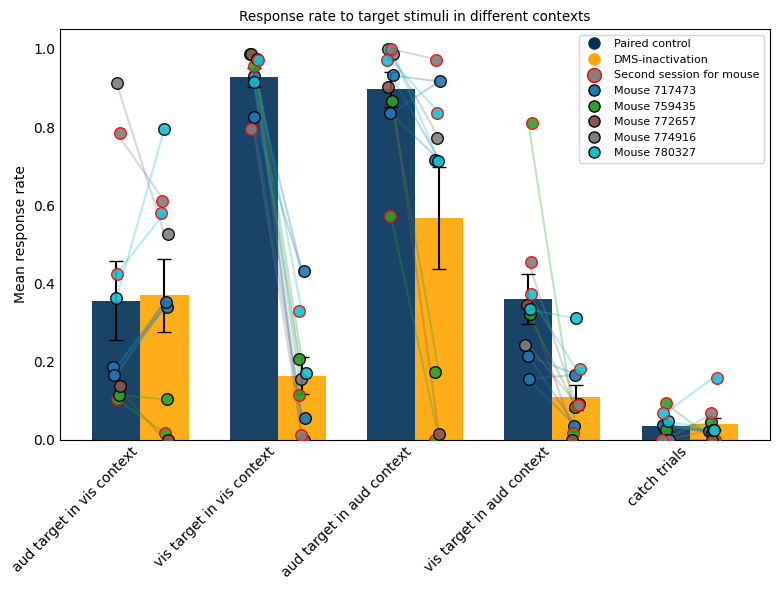

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_dms
muscimol_df_dms['mouse_id'] = muscimol_df_dms['session_id'].apply(extract_mouse_id)
muscimol_df_dms['date'] = muscimol_df_dms['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=4):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_dms, max_days=4)

# Create color map for mouse IDs
unique_mice = muscimol_df_dms['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_dms[muscimol_df_dms['control']].copy()
perturb_data = muscimol_df_dms[muscimol_df_dms['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='DMS-inactivation')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

## visp inactivations

In [27]:
muscimol_data_visp = []

def extract_base_id(session_id):
    return "_".join(session_id.split("_")[:-1])

#def(mouse, perturbation or control)
session_ids = ['716718_2024-08-02', '716718_2024-08-02', '715709_2024-08-09','716718_2024-07-30', '716718_2024-08-01', '715709_2024-08-07']
control = ['716718_2024-08-02', '716718_2024-08-02', '715709_2024-08-09']
perturbation = ['716718_2024-07-30', '716718_2024-08-01', '715709_2024-08-07']


# ['716718_2024-07-31', '715709_2024-08-08', '762526_2024-03-19', '802592_2024-09-19', '762526_2024-03-21']

# quiescent_violations = [47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]


for i, session_id in enumerate(session_ids):
    session = npc_sessions.Session(session_id)
   
    
#vis nontarget in vis context
    vis_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_vis_nontarget == True")
    vis_nontarget_vis_context_responses = (len(vis_nontarget_vis_context)) / (len(all_vis_nontargets_vis_context))

#aud nontarget in vis context
    aud_nontarget_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_vis_context = session.trials[:].query(
    "rewarded_modality == 'vis' & is_aud_nontarget == True")
    aud_nontarget_vis_context_responses = (len(aud_nontarget_vis_context)) / (len(all_aud_nontargets_vis_context))

# vis nontarget in aud context
    vis_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_response == True & is_vis_nontarget == True")
    all_vis_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_vis_nontarget == True")
    vis_nontarget_aud_context_responses = (len(vis_nontarget_aud_context)) / (len(all_vis_nontargets_aud_context))

#aud nontarget in aud context
    aud_nontarget_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True & is_response == True")
    all_aud_nontargets_aud_context = session.trials[:].query(
    "rewarded_modality == 'aud' & is_aud_nontarget == True")
    aud_nontarget_aud_context_responses = (len(aud_nontarget_aud_context)) / (len(all_aud_nontargets_aud_context))

#aud target in aud context
    aud_target_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'aud'")
    all_aud_targets_aud_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'aud'")
    auditory_target_in_auditory_context = (len(aud_target_responses_in_aud_context)/(len(all_aud_targets_aud_context)))

#vis target in vis context
    vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'vis'")
    all_vis_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'vis'")
    visual_target_in_visual_context = (len(vis_rewarded_responses_in_vis_context)/(len(all_vis_rewarded_responses_in_vis_context)))

#aud target in vis context
    aud_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_response == True & is_aud_target == True & rewarded_modality == 'vis'")
    all_rewarded_responses_in_vis_context = session.trials[:].query(
    "is_aud_target == True & rewarded_modality == 'vis'")
    auditory_target_in_visual_context = (len(aud_rewarded_responses_in_vis_context)/(len(all_rewarded_responses_in_vis_context)))

#vis target in aud context
    vis_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_response == True & is_vis_target == True & rewarded_modality == 'aud'")
    all_rewarded_responses_in_aud_context = session.trials[:].query(
    "is_vis_target == True & rewarded_modality == 'aud'")
    visual_target_in_auditory_context = (len(vis_rewarded_responses_in_aud_context)/(len(all_rewarded_responses_in_aud_context)))

#catch trials
    catch_responses = session.trials[:].query(
    'is_response == True & is_catch == True')
    all_catch = session.trials[:].query(
    'is_catch == True')
    catch_trials = (len(catch_responses)/(len(all_catch)))

#quiescent violations
    # quiescent_violations = [22, 66, 28, 69, 47, 42, 44, 79, 87, 209, 40, 66, 36, 88, 37, 74, 32, 82, 7, 21, 62, 47, 22, 34, 20, 56]
    # total_vis_quiescent_violations = [18, 45, 18, 33, 14, 17, 22, 22, 36, 73, 37, 24, 28, 35, 21, 23, 22, 40, 4, 8, 47, 17, 12, 25, 5, 23]
    # total_aud_quiescent_violations = [4, 21, 9, 27, 33, 24, 22, 55, 51, 129, 3, 37, 13, 49, 12, 51, 10, 42, 2, 13, 15, 30, 10, 9, 15, 31]
    # vis_quiescent_violations = [(18/22), (45/66), (18/28), (33/69), (14/47), (17/42), (22/44),(22/79), (36/87), (73/209), (37/40), (24/66), (28/36), (35/88), (21/37), (23/74), (22/32), (40/82), (4/7), (8/21), (47/62), (17/47), (12/22), (25/34), (5/20), (23/56)]
    # aud_quiescent_violations = [(4/22), (21/66), (9/28), (27/69), (33/47), (24/42), (22/44),(55/79), (51/87), (129/209),(3/40), (37/66), (13/36), (49/88), (12/37),(51/74), (10/32), (42/82), (2/7), (13/21), (15/62), (30/47), (10/22), (9/34), (15/20), (31/56)]

    result = dict(
                    session_id=session,
                    control = session_id in control,
                    perturbation = session_id in perturbation,
                    vis_nontarget_vis_context_responses=vis_nontarget_vis_context_responses,
                    aud_nontarget_vis_context_responses=aud_nontarget_vis_context_responses,
                    vis_nontarget_aud_context_responses=vis_nontarget_aud_context_responses,
                    aud_nontarget_aud_context_responses=aud_nontarget_aud_context_responses,
                    auditory_target_in_visual_context=auditory_target_in_visual_context,
                    visual_target_in_auditory_context=visual_target_in_auditory_context,
                    visual_target_in_visual_context=visual_target_in_visual_context,
                    auditory_target_in_auditory_context=auditory_target_in_auditory_context,
                    catch_trials=catch_trials,
                    # quiescent_violations=quiescent_violations[i],
                    # total_vis_quiescent_violations=total_vis_quiescent_violations[i],
                    # total_aud_quiescent_violations=total_aud_quiescent_violations[i],
                    # vis_quiescent_violations=vis_quiescent_violations[i],
                    # aud_quiescent_violations=aud_quiescent_violations[i]
                    )
    
#     if session in perturbation:
#             result['perturbation'] = True
#     else:
#             result['control'] = True

    muscimol_data_visp.append(result)

# print(muscimol_data)
muscimol_df_visp = pd.DataFrame(muscimol_data_visp)
print(muscimol_df_visp)

    # df = session_id, correct_vis_responses, correct_aud_responses, aggregated_correct_context_responses, control or perturbation session
    # new_df = mouse, session_id, averaged_aggregate_correct_responses_control_within_session, averaged_aggregate_correct_responses_perturbation_within_session, 
    # plot pair previous date with next date with sessions, and plot a population trend between those two sessions, color code by mouse



                                   session_id  control  perturbation  \
0  DynamicRoutingSession('716718_2024-08-02')     True         False   
1  DynamicRoutingSession('716718_2024-08-02')     True         False   
2  DynamicRoutingSession('715709_2024-08-09')     True         False   
3  DynamicRoutingSession('716718_2024-07-30')    False          True   
4  DynamicRoutingSession('716718_2024-08-01')    False          True   
5  DynamicRoutingSession('715709_2024-08-07')    False          True   

   vis_nontarget_vis_context_responses  aud_nontarget_vis_context_responses  \
0                             0.245902                             0.067797   
1                             0.245902                             0.067797   
2                             0.016949                             0.333333   
3                             0.017857                             0.071429   
4                             0.035088                             0.052632   
5                    

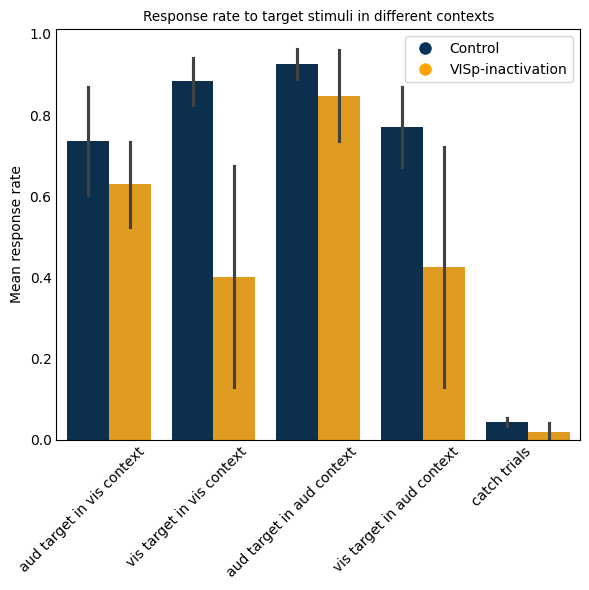

In [28]:
muscimol_df_visp['session_id'] = muscimol_df_visp['session_id'].astype(str)

avg_visp = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_visp[muscimol_df_visp['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_visp[muscimol_df_visp['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_visp[muscimol_df_visp['control']]['visual_target_in_visual_context'].values,
        muscimol_df_visp[muscimol_df_visp['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_visp[muscimol_df_visp['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_visp[muscimol_df_visp['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_visp[muscimol_df_visp['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_visp[muscimol_df_visp['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_visp[muscimol_df_visp['control']]['catch_trials'].values,
        muscimol_df_visp[muscimol_df_visp['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_visp_df = pd.DataFrame(avg_visp)

avg_visp_melted = avg_visp_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_visp_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'VISp-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()



C:\Users\vayle.lafehr\AppData\Local\Temp\ipykernel_9080\2371535809.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_mice))


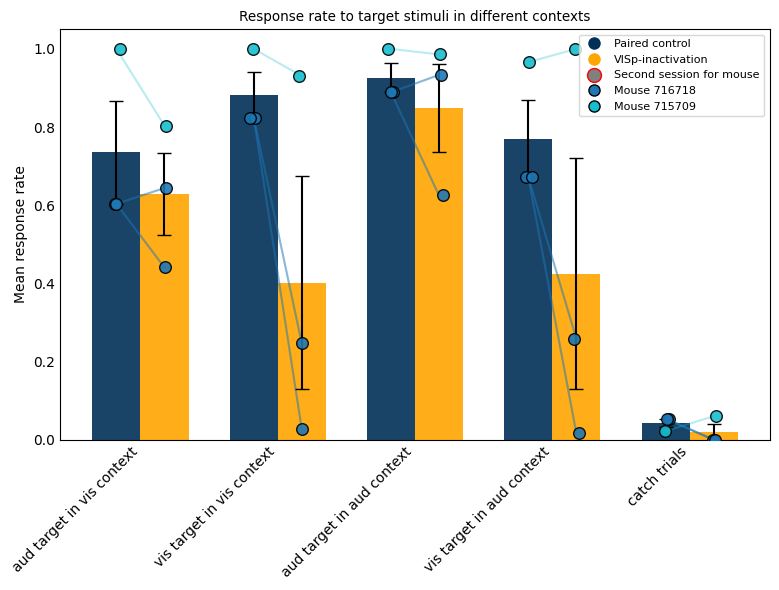

In [33]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import timedelta

# Extract mouse ID function
def extract_mouse_id(x):
    s = str(x)
    match = re.search(r"\('(\d+)_", s)
    if match:
        return match.group(1)
    if '_' in s:
        return s.split('_')[0].split('(')[-1].strip("'")
    return s

# Extract date function
def extract_date_from_session(session_id):
    s = str(session_id)
    match = re.search(r'(\d{4}-\d{2}-\d{2})', s)
    if match:
        try:
            return pd.to_datetime(match.group(1))
        except ValueError:
            pass
    return None

# Add mouse ID and date to muscimol_df_visp
muscimol_df_visp['mouse_id'] = muscimol_df_visp['session_id'].apply(extract_mouse_id)
muscimol_df_visp['date'] = muscimol_df_visp['session_id'].apply(extract_date_from_session)

# Identify sessions with gaps > 4 days FROM THE FIRST SESSION
def has_large_gap_from_first(df, max_days=8):
    """Returns set of session_ids that come >max_days after the FIRST session for that mouse"""
    df_sorted = df.sort_values(['mouse_id', 'date']).reset_index(drop=True)
    sessions_after_gap = set()
    
    for mouse_id in df_sorted['mouse_id'].unique():
        mouse_sessions = df_sorted[df_sorted['mouse_id'] == mouse_id].copy()
        
        if len(mouse_sessions) > 0:
            # Get the FIRST session date for this mouse
            first_date = mouse_sessions.iloc[0]['date']
            
            # Check all subsequent sessions against the FIRST date
            for i in range(1, len(mouse_sessions)):
                current_date = mouse_sessions.iloc[i]['date']
                days_from_first = abs((current_date - first_date).days)
                
                if days_from_first > max_days:
                    session_id = str(mouse_sessions.iloc[i]['session_id'])
                    sessions_after_gap.add(session_id)
    
    return sessions_after_gap

# Get sessions with gaps from first session
gap_sessions = has_large_gap_from_first(muscimol_df_visp, max_days=8)

# Create color map for mouse IDs
unique_mice = muscimol_df_visp['mouse_id'].unique()
colors = plt.cm.get_cmap('tab10', len(unique_mice))
mouse_color_map = {mouse: colors(i) for i, mouse in enumerate(unique_mice)}

# Separate control and perturbation data
control_data = muscimol_df_visp[muscimol_df_visp['control']].copy()
perturb_data = muscimol_df_visp[muscimol_df_visp['perturbation']].copy()

# Define categories
categories = ['aud target in vis context', 'vis target in vis context', 
              'aud target in aud context', 'vis target in aud context', 'catch trials']
columns = ['auditory_target_in_visual_context', 'visual_target_in_visual_context',
           'auditory_target_in_auditory_context', 'visual_target_in_auditory_context', 'catch_trials']

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate means and SEMs for each category
x_positions = np.arange(len(categories))
bar_width = 0.35

control_means = [control_data[col].mean() for col in columns]
control_sems = [control_data[col].sem() for col in columns]
perturb_means = [perturb_data[col].mean() for col in columns]
perturb_sems = [perturb_data[col].sem() for col in columns]

# Plot bars
ax.bar(x_positions - bar_width/2, control_means, bar_width, 
       yerr=control_sems, color='#003057', label='Control', capsize=5, alpha=0.9)
ax.bar(x_positions + bar_width/2, perturb_means, bar_width,
       yerr=perturb_sems, color='#FFA500', label='Perturbation', capsize=5, alpha=0.9)

# Draw lines connecting paired points (same mouse, within 3 days)
for i, col in enumerate(columns):
    for _, control_row in control_data.iterrows():
        mouse_id = control_row['mouse_id']
        control_date = control_row['date']
        control_val = control_row[col]
        
        # Find matching perturbation sessions for this mouse within 3 days
        matching_perturb = perturb_data[
            (perturb_data['mouse_id'] == mouse_id) &
            (abs((perturb_data['date'] - control_date).dt.days) <= 3)
        ]
        
        for _, perturb_row in matching_perturb.iterrows():
            perturb_val = perturb_row[col]
            # Draw line
            ax.plot([i - bar_width/2, i + bar_width/2], 
                   [control_val, perturb_val],
                   color=mouse_color_map[mouse_id], 
                   alpha=0.3, linewidth=1.5, zorder=1)

# Add individual data points with JITTER and RED BORDER for gap sessions
jitter_amount = 0.03  # Adjust this value to control spacing

for i, col in enumerate(columns):
    # Control points with jitter
    for idx, row in control_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i - bar_width/2 + jitter, row[col], 
                  color=mouse_color_map[row['mouse_id']], 
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1, 
                  zorder=3)
    
    # Perturbation points with jitter
    for idx, row in perturb_data.iterrows():
        jitter = np.random.uniform(-jitter_amount, jitter_amount)
        session_str = str(row['session_id'])
        has_gap = session_str in gap_sessions
        
        ax.scatter(i + bar_width/2 + jitter, row[col],
                  color=mouse_color_map[row['mouse_id']],
                  edgecolors='red' if has_gap else 'black',
                  s=70, alpha=0.9, 
                  linewidth=1 if has_gap else 1,
                  zorder=3)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.tick_params(axis='both', which='both', length=0)
ax.set_ylabel('Mean response rate', fontsize=10)
ax.set_title('Response rate to target stimuli in different contexts', fontsize=9.75)

# Create ALL legend handles in one list
condition_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10, label='Paired control'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10, label='VISp-inactivation')
]

gap_handle = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markeredgecolor='red', markersize=10, linewidth=2.5, 
                        label='Second session for mouse')]

mouse_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=mouse_color_map[mouse], 
               markeredgecolor='black', markersize=8, linewidth=1, label=f'Mouse {mouse}')
    for mouse in unique_mice
]

# Combine ALL handles into ONE legend
all_handles = condition_handles + gap_handle + mouse_handles
ax.legend(handles=all_handles, loc='upper right', frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

In [6]:
import npc_stim

npc_stim.get_running_speed_from_hdf5('s3://aind-private-data-prod-o5171v/ecephys_716718_2024-07-31_15-21-30/behavior/DynamicRouting1_716718_20240731_144658.hdf5')

array([       nan, 1.72664877, 1.07915548, ..., 1.07915548, 1.07915548,
       1.51081768])

In [12]:
session = npc_sessions.Session('s3://aind-private-data-prod-o5171v/ecephys_716718_2024-07-31_15-21-30/behavior/DynamicRouting1_716718_20240731_144658.hdf5')

In [ ]:
session

AttributeError: No trials table available for 716718_2024-07-31: self.is_task=False

In [ ]:
muscimol_df_orbm['session_id'] = muscimol_df_orbm['session_id'].astype(str)

avg_orbm = {
    'Condition': ['Control', 'Perturbation'],

    # 'both targets': [
    # muscimol_df[muscimol_df['control']]['both_targets'].mean(),
    # muscimol_df[muscimol_df['perturbation']]['both_targets'].mean()
    # ],
    # 'auditory target':[
    #     muscimol_df[muscimol_df['control']]['auditory_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['auditory_target'].mean()
    # ],
    # 'visual target':[
    #     muscimol_df[muscimol_df['control']]['visual_target'].mean(),
    #     muscimol_df[muscimol_df['perturbation']]['visual_target'].mean()
    # ],
     'aud target in vis context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['auditory_target_in_visual_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['auditory_target_in_visual_context'].values
    ],
     'vis target in vis context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['visual_target_in_visual_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['visual_target_in_visual_context'].values
    ],
     'aud target in aud context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['auditory_target_in_auditory_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['auditory_target_in_auditory_context'].values
    ],
     'vis target in aud context':[
        muscimol_df_orbm[muscimol_df_orbm['control']]['visual_target_in_auditory_context'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['visual_target_in_auditory_context'].values
    ],

    'catch trials' :[
        muscimol_df_orbm[muscimol_df_orbm['control']]['catch_trials'].values,
        muscimol_df_orbm[muscimol_df_orbm['perturbation']]['catch_trials'].values
    ]

}

# Create a DataFrame from the dictionary
avg_orbm_df = pd.DataFrame(avg_orbm)

avg_orbm_melted = avg_orbm_df.melt(id_vars='Condition', var_name='Category', value_name='Mean Value')

# Plotting the bar plot
plt.figure(figsize=(6, 6))
ax = sns.barplot(x='Category', y='Mean Value', hue='Condition', errorbar='se',
                 data=avg_orbm_melted.explode('Mean Value'), palette=['#003057', '#FFA500'])

plt.xlabel('')
plt.xticks(rotation = 45)
current_ticks = ax.get_xticks()
new_ticks = [tick - 0.25 for tick in current_ticks] # Adjust the value as needed
ax.set_xticks(new_ticks)

ax.tick_params(axis='both', which='both', length=0)


plt.ylabel('Mean response rate', fontsize = 10)
plt.title('Response rate to target stimuli in different contexts', fontsize = 9.75)
# plt.legend(loc='upper right')
# plt.legend(['Control', 'ORB-lesion'])
# plt.show()
plt.tight_layout()

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#003057', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFA500', markersize=10)]
labels = ['Control', 'ORBm-inactivation']
plt.legend(handles, labels, loc='upper right')
            # bbox_to_anchor=(1, 1))

plt.tight_layout()

# plt.savefig(r"C:\Users\vayle.lafehr\Desktop\perturbation_analysis_figures\mean_response_rate_targets.png", dpi=300)

plt.show()
# for condition in ['Control', 'Perturbation']:
#     for category in avg_values.keys():
#         if category != 'Condition':
#             x_coords = avg_values_melted[(avg_values_melted['Condition'] == condition) & (avg_values_melted['Category'] == category)].index[0]
#             y_coords = muscimol_df_orb.loc[muscimol_df_orb[condition.lower()], category.lower().replace(' ', '_').replace('-', '_')].values
#             plt.scatter([x_coords + (0.2 if condition == 'Perturbation' else -0.2)]*len(y_coords), y_coords, color='black', alpha=0.5)


# new_labels = ['all target stimuli', 'auditory target', 'visual target', 'auditory target in visual context', 'visual target in visual context', 'auditory target in auditory context','visual target in auditory context', 'catch trials' ]
# # ax.set_xticklabels(new_labels, fontsize = 12, rotation=35,)



# # Show the plot
# plt.tight_layout()
# plt.show()

